<a href="https://colab.research.google.com/github/adawongHL/ML_project_F24/blob/main/supervised_neural_network_DONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#pip install liac-arff numpy pandas scikit-learn matplotlib seaborn

In [ ]:
'''
To-do
- add hyperparam for different learning rates
-

Overview:
# Supervised Learning: Neural Network
## To-do
- [A] Setup
- [B] Data Pre-processing
- [C] Training
- [D] Evaluation
- [E] Visualization
- [F] Feature Transformations (at least 3 types)
- [G] Regularization (at least 6 values)
'''

'\nTo-do\n- add hyperparam for different learning rates\n-\n\nOverview:\n# Supervised Learning: Neural Network\n## To-do\n- [A] Setup\n- [B] Data Pre-processing\n- [C] Training\n- [D] Evaluation\n- [E] Visualization\n- [F] Feature Transformations (at least 3 types)\n- [G] Regularization (at least 6 values)\n'

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# helper functions
# Confusion Matrix Structure:
#             Predicted
#             0       1
# True   0   [ TN   FP ]
#        1   [ FN   TP ]

def get_recall(confusion_matrix):
  TN, FP, FN, TP = confusion_matrix.ravel() # returns 1D copy
  recall = TP / (TP + FN) if (TP + FN) != 0 else 0.0
  return round(recall,2)

def get_precision(confusion_matrix):
  TN, FP, FN, TP = confusion_matrix.ravel() # returns 1D copy
  precision = TP / (TP + FP) if (TP + FP) != 0 else 0.0
  return round(precision,2)

def visualize_ROC_plot(y_true, y_predict_prob, class_mapping=None, title='ROC Curve'):
  if class_mapping:
      y_true_numeric = y_true.replace(class_mapping)
  else:
      y_true_numeric = y_true

  # Compute ROC curve and AUC (area under curve)
  fpr, tpr, _ = metrics.roc_curve(y_true_numeric, y_predict_prob)
  auc = metrics.roc_auc_score(y_true_numeric, y_predict_prob)

  # Plot
  plt.figure()
  plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(title)
  plt.legend(loc='lower right')
  plt.show()

  return auc

def get_confusion_matrix(y_true, y_pred):
  cnf_matrix = metrics.confusion_matrix(y_true, y_pred)
  return cnf_matrix

def display_metrics(y_true, y_pred, cnf_matrix, target_names):
  print(metrics.classification_report(y_true, y_pred, target_names=target_names))
  accuracy = metrics.classification_report(y_true, y_pred, target_names=target_names)[219:223]
  print(f"Accuracy: {accuracy}")
  print(f"Recall: {get_recall(cnf_matrix)}")
  print(f"Precision: {get_precision(cnf_matrix)}")

def visualize_confusion_matrix(cnf_matrix, class_names, title="Confusion Matrix"):
  fig, ax = plt.subplots()
  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names)
  plt.yticks(tick_marks, class_names)

  # Create heatmap using seaborn
  sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="coolwarm", fmt='g')
  ax.xaxis.set_label_position("top")
  plt.tight_layout()
  plt.title(title, y=1.05)  # y-coordinate for title
  plt.xlabel('Predicted label')
  ax.xaxis.set_label_position("bottom")
  plt.ylabel('True label')

In [ ]:
## [A] Setup: Load the dataset
with open('dataset_31_credit-g.arff', 'r') as file:
    data, metadata = arff.loadarff(file)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Convert byte strings to strings in data entries
df = df.map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# CHECK
# Display column names (all strs)
col_count = 0
for column in df.columns:
    col_count += 1
    # print(f"Column: {column}, Type: {type(column)}")
# print(f"Total Number of columns = {col_count}") # 20 input features; last column is "class" (true label)

# Display the first few rows
# print(f"Total number of data entries = {data.size}")
# print(df.head())

# SECTION [A] DONE ✅
# <------------------------------------------------------------------------------------------------------------------------>

## [B] Data preprocessing

# Check for missing values and drop them
# print(df.isnull().sum())
df = df.dropna()

# Strip and lowercase all column names for consistency
df.columns = [col.strip().lower() for col in df.columns]

# print(f"Columns before one-hot-encode: {df.columns}")
# print(f"Total Columns: {len(df.columns)}")

## ONE-HOT ENCODING (no natural order)
columns_to_one_hot_encode = ["credit_history", "purpose", "personal_status", "other_parties", "property_magnitude", "other_payment_plans", "housing", "own_telephone", "foreign_worker"]
columns_to_one_hot_encode = [col.strip().lower() for col in columns_to_one_hot_encode]
df = pd.get_dummies(df, columns=columns_to_one_hot_encode)
# print(f"Columns after one-hot-encode: {df.columns}")
# print(f"Total Columns: {len(df.columns)}")

# ORDINAL ENCODING (with natural order)
columns_for_ordinal_encoding = ["checking_status", "savings_status", "employment", "job"]
columns_for_ordinal_encoding = [col.strip().lower() for col in columns_for_ordinal_encoding]
# Ordinal Encoding (Custom)
# Note: Not using OrdinalEncode() because it assigns arbitrarily-ordered values for ordinal columns

# checking_status order
checking_status_mapping = {
    'no checking': 0,
    '<0': 1,
    '0<=X<200': 2,
    '>=200': 3,
}
df['checking_status'] = df['checking_status'].replace(checking_status_mapping)
# print(df['checking_status'].head())

# savings_status order
savings_status_mapping = {
    'no known savings': 0,
    '<100': 1,
    '100<=X<500': 2,
    '500<=X<1000': 3,
    '>=1000': 4
}
df['savings_status'] = df['savings_status'].replace(savings_status_mapping)

# employment order
employment_mapping = {
    'unemployed': 0,
    '<1': 1,
    '1<=X<4': 2,
    '4<=X<7': 3,
    '>=7': 4
}
df['employment'] = df['employment'].replace(employment_mapping)

# job order
job_mapping = {
    'unemp/unskilled non res': 0,
    'unskilled resident': 1,
    'skilled': 2,
    'high qualif/self emp/mgmt': 3
}
df['job'] = df['job'].replace(job_mapping)

# CHECK
# print("Categorical variables encoded! Before standardizing......")
# print(df['job'].head(5))


## STANDARDIZATION (change values s.t. mean=0, var=1 for all numerical and ordinal columns)
# Note: Exclude one-hot encoded columns and true label column
one_hot_encoded_columns = [col for col in df.columns if any(prefix in col for prefix in columns_to_one_hot_encode)]
X_to_scale = df.drop(one_hot_encoded_columns + ['class'], axis=1)
y = df['class']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_to_scale)

# Convert scaled_data back to DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=X_to_scale.columns)

# Combine scaled data with one-hot encoded columns
scaled_X = pd.concat([scaled_data, df[one_hot_encoded_columns]], axis=1) # true label column excluded
# print("After standardizing data......")
# print(scaled_X['job'].head(5))
# print(y.head())
# print(type(y))
# print(type(scaled_X))

# Notes:
# "scaled_X" contains input data (standardized and encoded); we will split "scaled_X" for training, validation and testing
# "y" contains true labels

## SPLIT THE DATASET
# 80/10/10% for training, validation and test sets
# First split: 80% training, 20% remaining
X_train, X_temp, y_train, y_temp = train_test_split(scaled_X, y, test_size=0.2, random_state=42)

# Second split: 50% of the remaining 20% for validation and test (10% each of the original dataset)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Verify set sizes
print("Training set size:", X_train.shape, y_train.shape) # use for initial training of model
print("Validation set size:", X_val.shape, y_val.shape) # use for tuning regularization hyperparameters
print("Test set size:", X_test.shape, y_test.shape) # use for final evaluation of model performance

# SECTION [B] DONE ✅

Training set size: (800, 47) (800,)
Validation set size: (100, 47) (100,)
Test set size: (100, 47) (100,)


In [ ]:
## [C] Training: Neural Network, sigmoid as activation function (no regularization)
# Use MLPClassifier with the sigmoid activation function
hidden_layers_amounts = [2, 10, 15, 30]
num_hidden_layers = hidden_layers_amounts[0]
model = MLPClassifier(hidden_layer_sizes=(num_hidden_layers,), activation='logistic', solver='adam', max_iter=1000)
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
y_predict_train = model.predict(X_train)
# print(y_predict[:5])
# print(y_test[:5])
# SECTION [C] DONE ✅

In [ ]:
## [D] Evaluation: use test set
# Confusion Matrix
cnf_matrix = get_confusion_matrix(y_test, y_predict)
cnf_matrix_train = get_confusion_matrix(y_train, y_predict_train)

# Structure of Confusion Matrix:
# * Top-left-bottom-right Diagonal = correct predictions
# * 0 for "bad", 1 for "good" credit risk
#             Predicted
#             0       1
# True   0   [ TN   FP ]
#        1   [ FN   TP ]

# Evaluation Metrics
target_names = ['bad credit risk', 'good credit risk']
print("Metrics on test set:")
print(f"Confusion Matrix (on test set):\n {cnf_matrix}")
display_metrics(y_test, y_predict, cnf_matrix, target_names=target_names)

print("--------------------------------------------------------")

print("Metrics on training set:")
print(f"Confusion Matrix (on training set):\n {cnf_matrix_train}")
display_metrics(y_train, y_predict_train, cnf_matrix_train, target_names=target_names)

# SECTION [D] DONE ✅

Metrics on test set:
Confusion Matrix (on test set):
 [[ 7 21]
 [11 61]]
                  precision    recall  f1-score   support

 bad credit risk       0.39      0.25      0.30        28
good credit risk       0.74      0.85      0.79        72

        accuracy                           0.68       100
       macro avg       0.57      0.55      0.55       100
    weighted avg       0.64      0.68      0.66       100

Accuracy: 0.68
Recall: 0.85
Precision: 0.74
--------------------------------------------------------
Metrics on training set:
Confusion Matrix (on training set):
 [[116 125]
 [ 67 492]]
                  precision    recall  f1-score   support

 bad credit risk       0.63      0.48      0.55       241
good credit risk       0.80      0.88      0.84       559

        accuracy                           0.76       800
       macro avg       0.72      0.68      0.69       800
    weighted avg       0.75      0.76      0.75       800

Accuracy: 0.76
Recall: 0.88
Precision: 

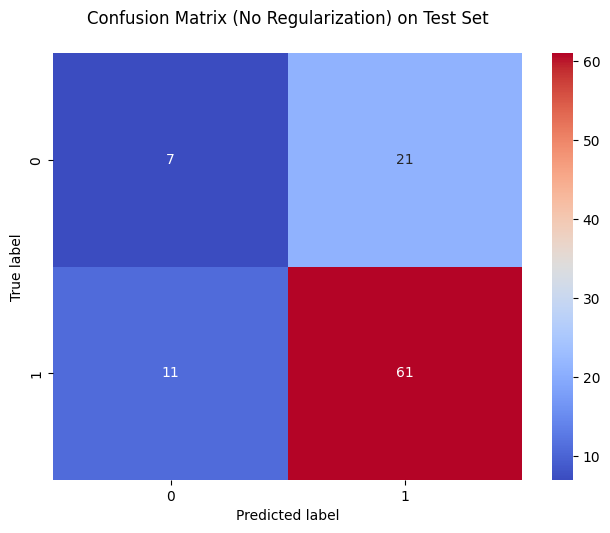

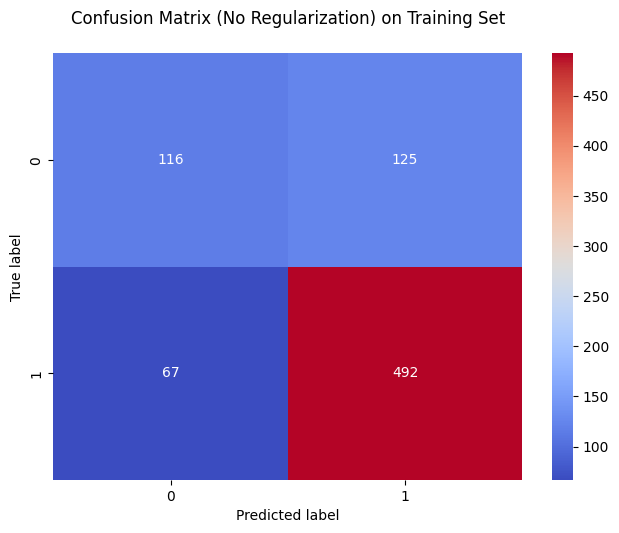

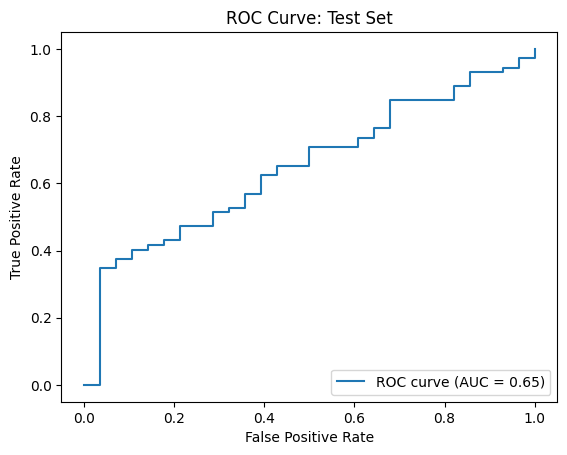

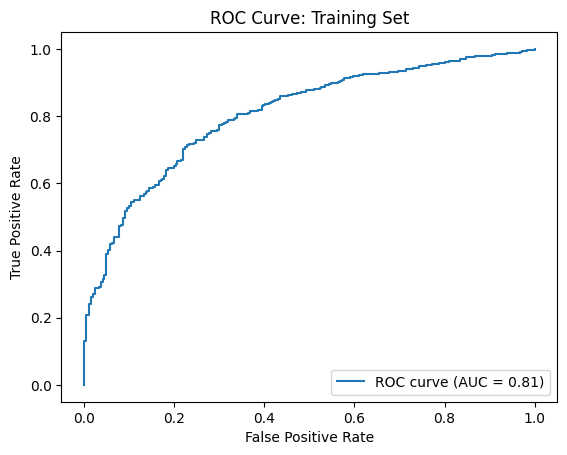

0.805528544600242

In [ ]:
## [E] Visualization
# Confusion Matrix
class_names=[0,1]

visualize_confusion_matrix(cnf_matrix, class_names, "Confusion Matrix (No Regularization) on Test Set")
visualize_confusion_matrix(cnf_matrix_train, class_names, "Confusion Matrix (No Regularization) on Training Set")

class_mapping = {'bad': 0, 'good': 1}
y_predict_prob = model.predict_proba(X_test)[::,1]
y_predict_prob_train = model.predict_proba(X_train)[::,1]

visualize_ROC_plot(y_test, y_predict_prob, class_mapping=class_mapping, title="ROC Curve: Test Set")
visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve: Training Set")

# SECTION [E] DONE ✅

---------------------------------------------------------------------
Trying 10 hidden layers............................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[17 14]
 [ 9 60]]
                  precision    recall  f1-score   support

 bad credit risk       0.65      0.55      0.60        31
good credit risk       0.81      0.87      0.84        69

        accuracy                           0.77       100
       macro avg       0.73      0.71      0.72       100
    weighted avg       0.76      0.77      0.76       100

Accuracy: 0.77
Recall: 0.87
Precision: 0.81
Metrics on training set:
Confusion Matrix (on training set):
 [[139 102]
 [ 44 515]]
                  precision    recall  f1-score   support

 bad credit risk       0.76      0.58      0.66       241
good credit risk       0.83      0.92      0.88       559

        accuracy                           0.82       800
       macro avg       0.80      0.75      0.77       800
    weighted avg       0.81      0.82      0.81       800

Accuracy: 0.82
Recall: 0.92
Precision: 0.83
----------------------------------------

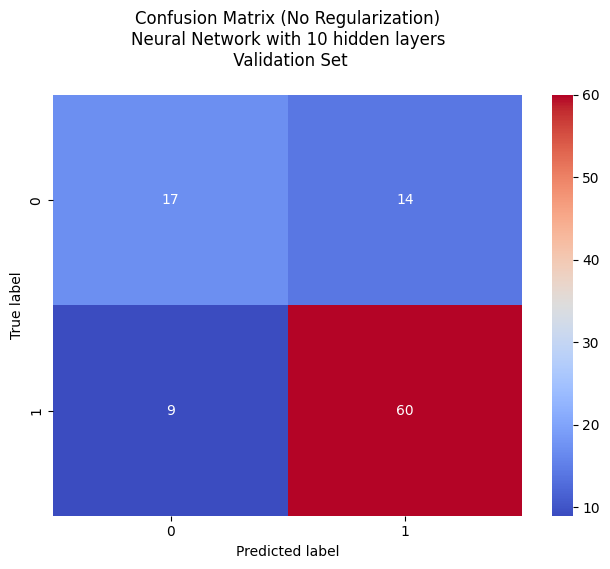

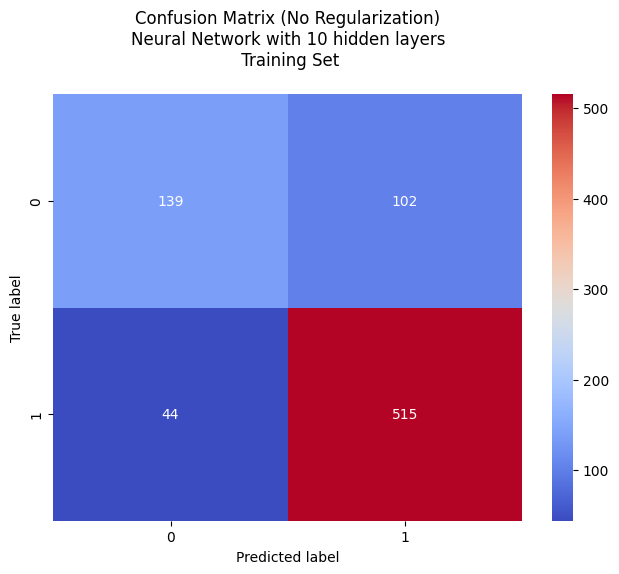

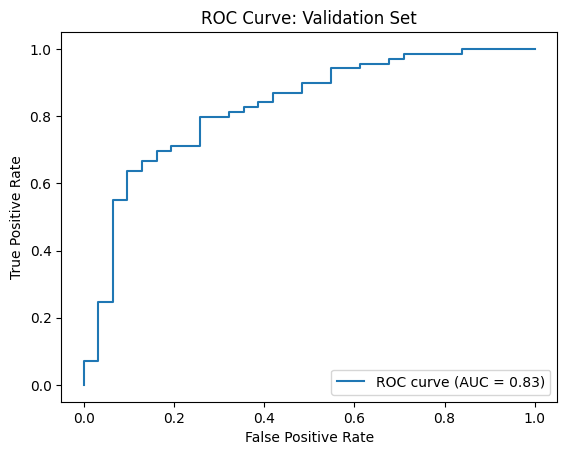

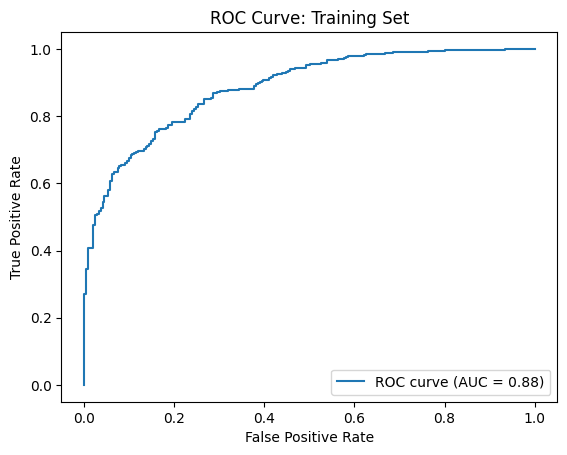

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying 15 hidden layers............................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[18 13]
 [ 9 60]]
                  precision    recall  f1-score   support

 bad credit risk       0.67      0.58      0.62        31
good credit risk       0.82      0.87      0.85        69

        accuracy                           0.78       100
       macro avg       0.74      0.73      0.73       100
    weighted avg       0.77      0.78      0.78       100

Accuracy: 0.78
Recall: 0.87
Precision: 0.82
Metrics on training set:
Confusion Matrix (on training set):
 [[163  78]
 [ 35 524]]
                  precision    recall  f1-score   support

 bad credit risk       0.82      0.68      0.74       241
good credit risk       0.87      0.94      0.90       559

        accuracy                           0.86       800
       macro avg       0.85      0.81      0.82       800
    weighted avg       0.86      0.86      0.85       800

Accuracy: 0.86
Recall: 0.94
Precision: 0.87
----------------------------------------

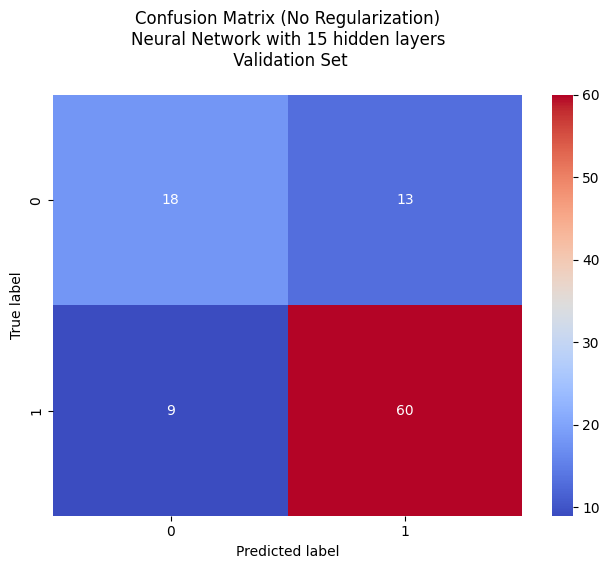

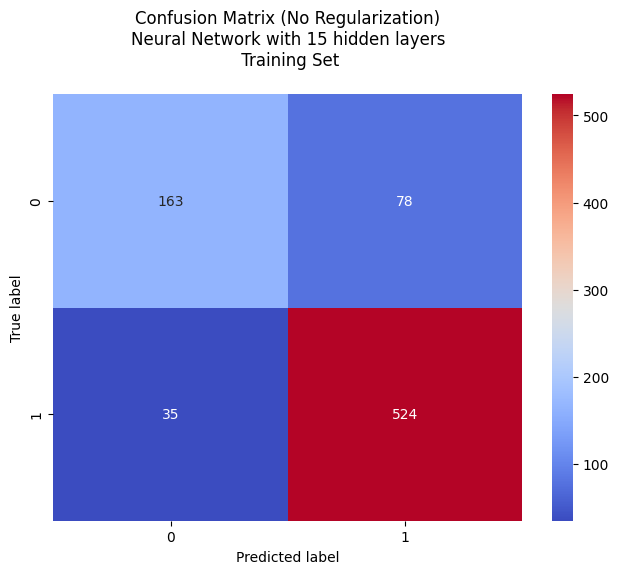

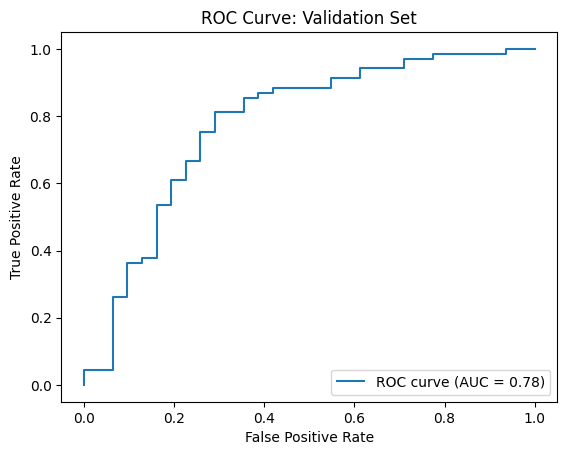

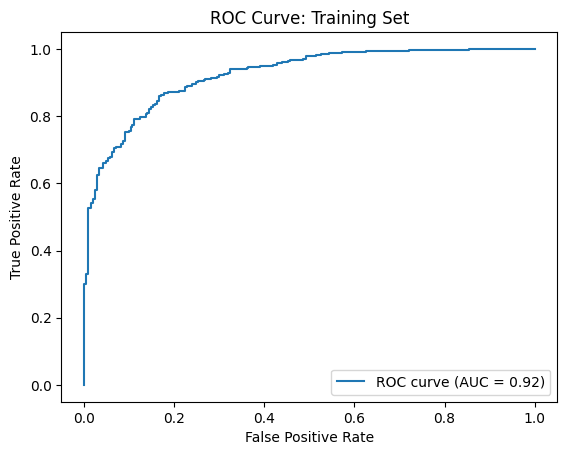

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying 30 hidden layers............................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[20 11]
 [ 9 60]]
                  precision    recall  f1-score   support

 bad credit risk       0.69      0.65      0.67        31
good credit risk       0.85      0.87      0.86        69

        accuracy                           0.80       100
       macro avg       0.77      0.76      0.76       100
    weighted avg       0.80      0.80      0.80       100

Accuracy: 0.80
Recall: 0.87
Precision: 0.85
Metrics on training set:
Confusion Matrix (on training set):
 [[194  47]
 [ 25 534]]
                  precision    recall  f1-score   support

 bad credit risk       0.89      0.80      0.84       241
good credit risk       0.92      0.96      0.94       559

        accuracy                           0.91       800
       macro avg       0.90      0.88      0.89       800
    weighted avg       0.91      0.91      0.91       800

Accuracy: 0.91
Recall: 0.96
Precision: 0.92
----------------------------------------

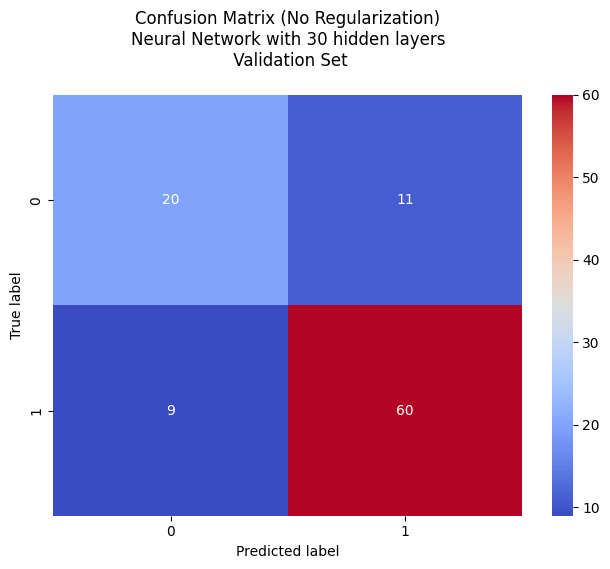

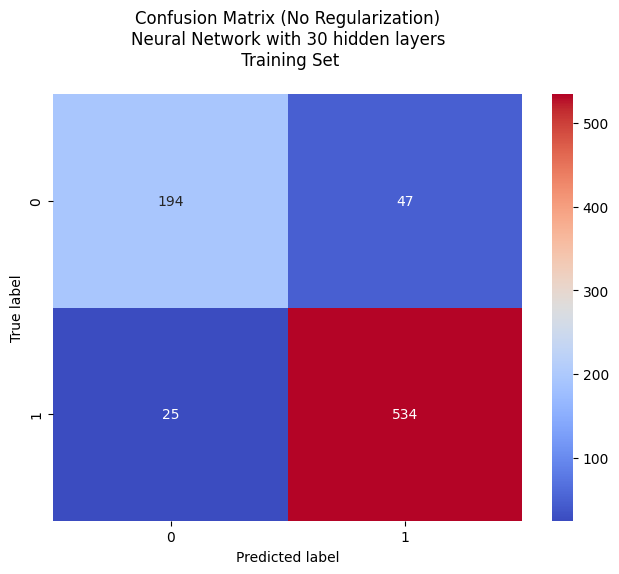

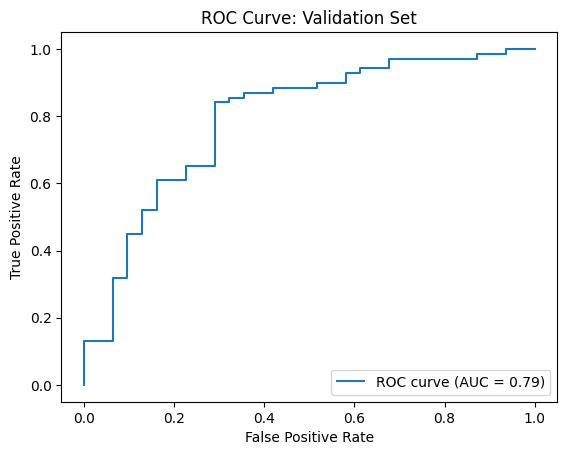

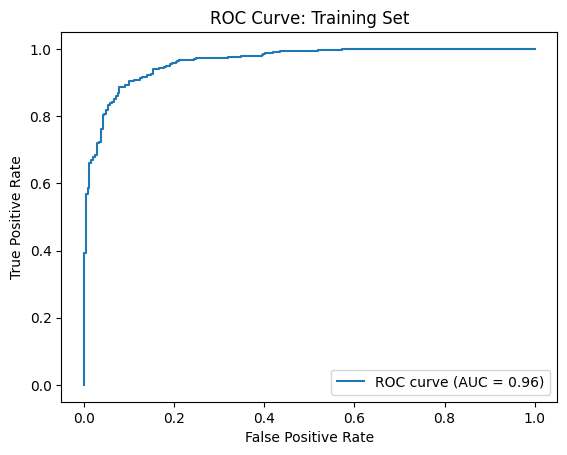

---------------------------------------------------------------------
The best number of hidden layers is 10 with auc = 0.8260869565217391 on validation set.


In [ ]:
## [F] Different architectures (at least 3 types)
# Try different amounts of hidden layers in the neural network
# Use validation set! (# of hidden layers is a hyperparameter)
# Previously:
  # hidden_layers_amounts = [2, 10, 15, 30]
  # num_hidden_layers = hidden_layers_amounts[0]

best_hidden_layers = 2
best_auc_for_hidden_layers = -1

for i in range(1, len(hidden_layers_amounts)):
  num_hidden_layers = hidden_layers_amounts[i]
  print("---------------------------------------------------------------------")
  print(f"Trying {num_hidden_layers} hidden layers............................")
  model = MLPClassifier(hidden_layer_sizes=(num_hidden_layers,), activation='logistic', solver='adam', max_iter=1000)
  model.fit(X_train, y_train)
  y_predict = model.predict(X_val)
  y_predict_train = model.predict(X_train)

  # Metrics
  cnf_matrix = get_confusion_matrix(y_val, y_predict)
  cnf_matrix_train = get_confusion_matrix(y_train, y_predict_train)

  print("Metrics on validation set:")
  print(f"Confusion Matrix (on validation set):\n {cnf_matrix}")
  display_metrics(y_val, y_predict, cnf_matrix, target_names=target_names)

  print("Metrics on training set:")
  print(f"Confusion Matrix (on training set):\n {cnf_matrix_train}")
  display_metrics(y_train, y_predict_train, cnf_matrix_train, target_names=target_names)

  print("--------------------------------------------------------")

  # Visualize
  visualize_confusion_matrix(cnf_matrix, class_names, f"Confusion Matrix (No Regularization)\nNeural Network with {num_hidden_layers} hidden layers\n Validation Set")
  visualize_confusion_matrix(cnf_matrix_train, class_names, f"Confusion Matrix (No Regularization)\nNeural Network with {num_hidden_layers} hidden layers\n Training Set")
  y_predict_prob = model.predict_proba(X_val)[::,1]
  y_predict_prob_train = model.predict_proba(X_train)[::,1]

  auc = visualize_ROC_plot(y_val, y_predict_prob, class_mapping=class_mapping, title="ROC Curve: Validation Set")
  visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve: Training Set")

  if auc > best_auc_for_hidden_layers:
    best_auc_for_hidden_layers = auc
    best_hidden_layers = num_hidden_layers

  print("---------------------------------------------------------------------")

print(f"The best number of hidden layers is {best_hidden_layers} with auc = {best_auc_for_hidden_layers} on validation set.")

# SECTION [F] DONE ✅

---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 1e-06..................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[17 14]
 [ 7 62]]
                  precision    recall  f1-score   support

 bad credit risk       0.71      0.55      0.62        31
good credit risk       0.82      0.90      0.86        69

        accuracy                           0.79       100
       macro avg       0.76      0.72      0.74       100
    weighted avg       0.78      0.79      0.78       100

Accuracy: 0.79
Recall: 0.9
Precision: 0.82
Metrics on training set:
Confusion Matrix (on training set):
 [[155  86]
 [ 42 517]]
                  precision    recall  f1-score   support

 bad credit risk       0.79      0.64      0.71       241
good credit risk       0.86      0.92      0.89       559

        accuracy                           0.84       800
       macro avg       0.82      0.78      0.80       800
    weighted avg       0.84      0.84      0.83       800

Accuracy: 0.84
Recall: 0.92
Precision: 0.86


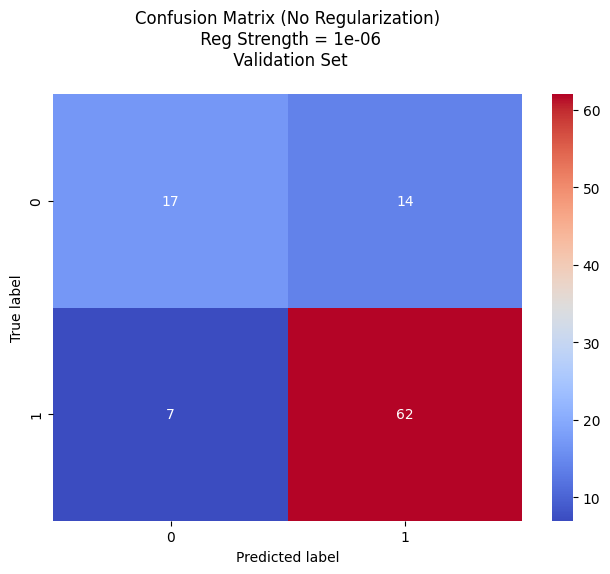

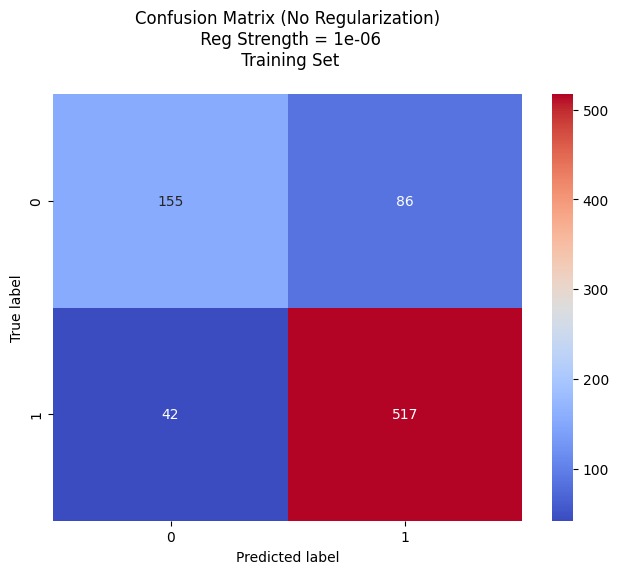

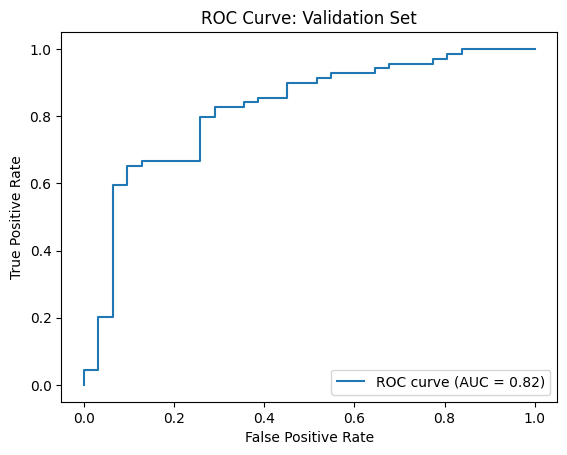

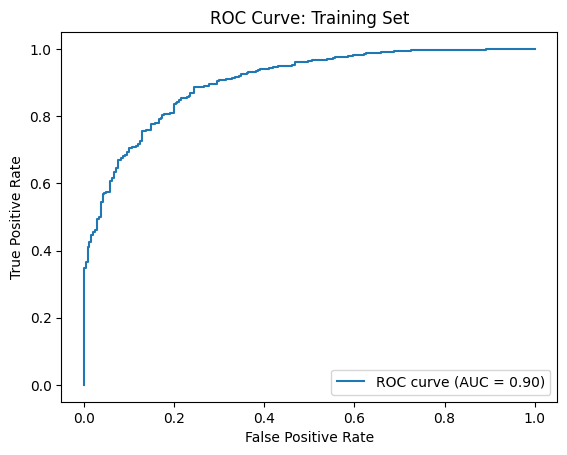

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 0.0001..................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[15 16]
 [ 7 62]]
                  precision    recall  f1-score   support

 bad credit risk       0.68      0.48      0.57        31
good credit risk       0.79      0.90      0.84        69

        accuracy                           0.77       100
       macro avg       0.74      0.69      0.70       100
    weighted avg       0.76      0.77      0.76       100

Accuracy: 0.77
Recall: 0.9
Precision: 0.79
Metrics on training set:
Confusion Matrix (on training set):
 [[151  90]
 [ 39 520]]
                  precision    recall  f1-score   support

 bad credit risk       0.79      0.63      0.70       241
good credit risk       0.85      0.93      0.89       559

        accuracy                           0.84       800
       macro avg       0.82      0.78      0.80       800
    weighted avg       0.84      0.84      0.83       800

Accuracy: 0.84
Recall: 0.93
Precision: 0.85


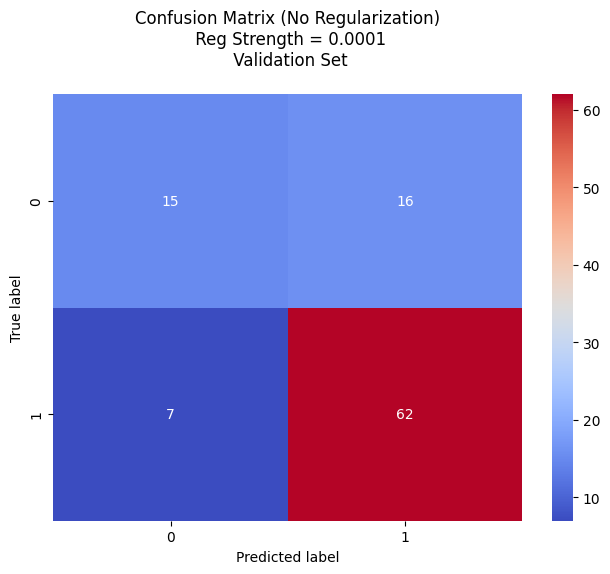

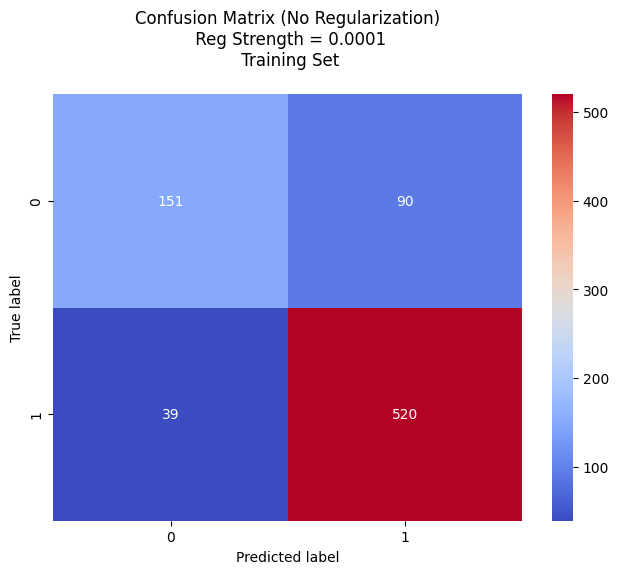

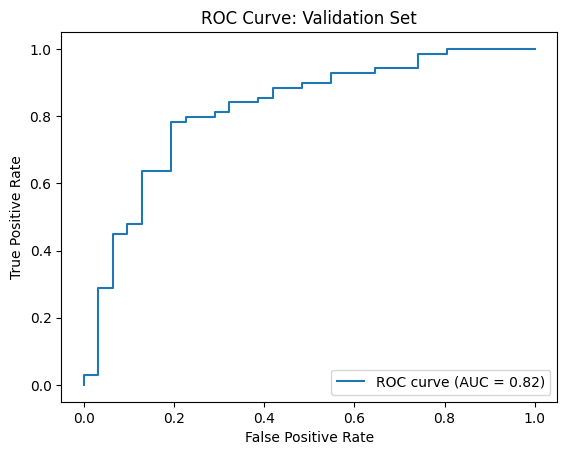

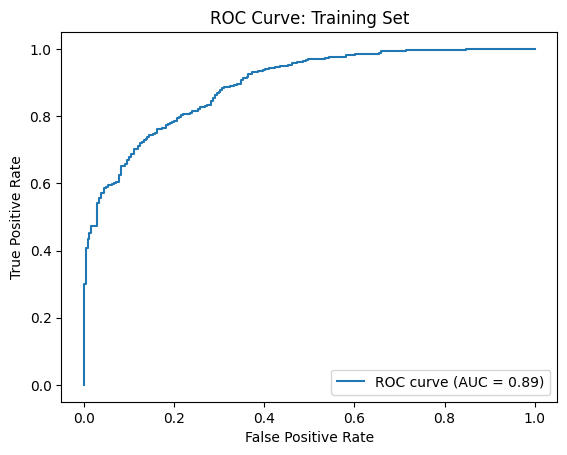

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 0.01..................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[16 15]
 [ 8 61]]
                  precision    recall  f1-score   support

 bad credit risk       0.67      0.52      0.58        31
good credit risk       0.80      0.88      0.84        69

        accuracy                           0.77       100
       macro avg       0.73      0.70      0.71       100
    weighted avg       0.76      0.77      0.76       100

Accuracy: 0.77
Recall: 0.88
Precision: 0.8
Metrics on training set:
Confusion Matrix (on training set):
 [[151  90]
 [ 36 523]]
                  precision    recall  f1-score   support

 bad credit risk       0.81      0.63      0.71       241
good credit risk       0.85      0.94      0.89       559

        accuracy                           0.84       800
       macro avg       0.83      0.78      0.80       800
    weighted avg       0.84      0.84      0.84       800

Accuracy: 0.84
Recall: 0.94
Precision: 0.85


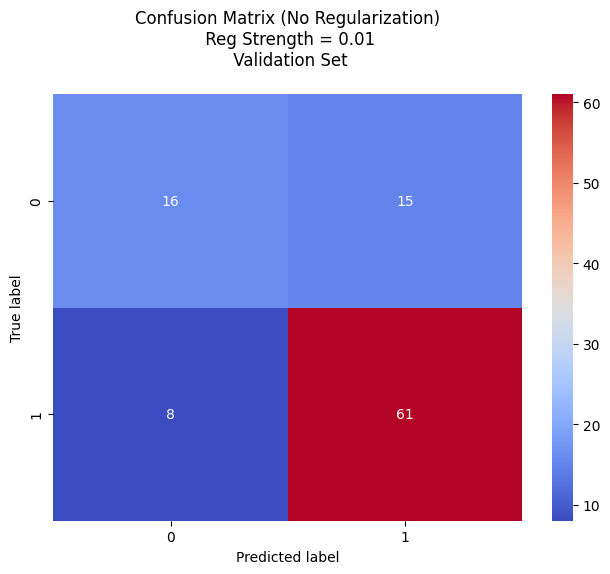

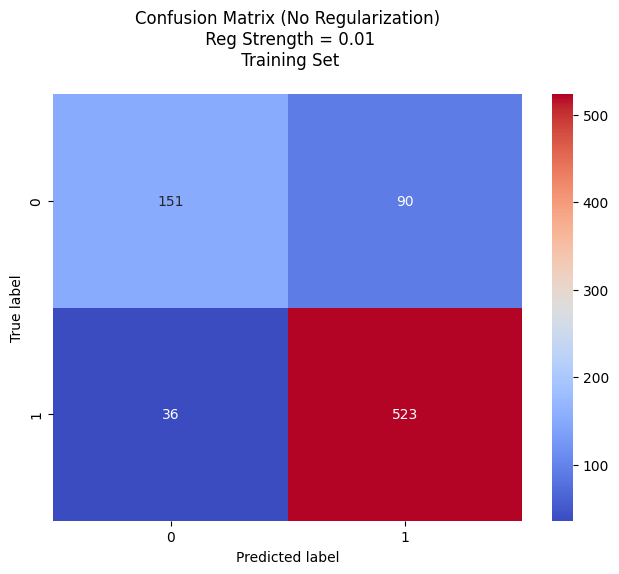

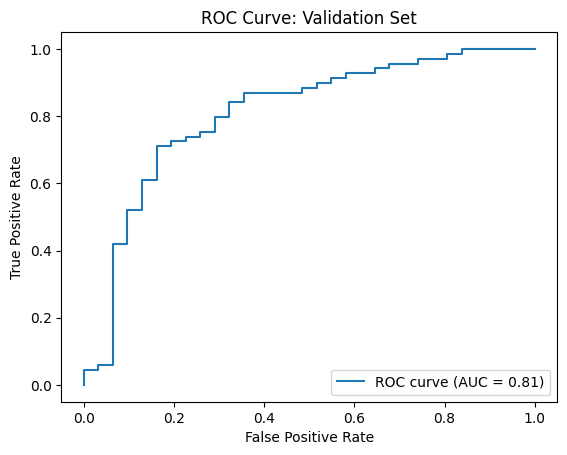

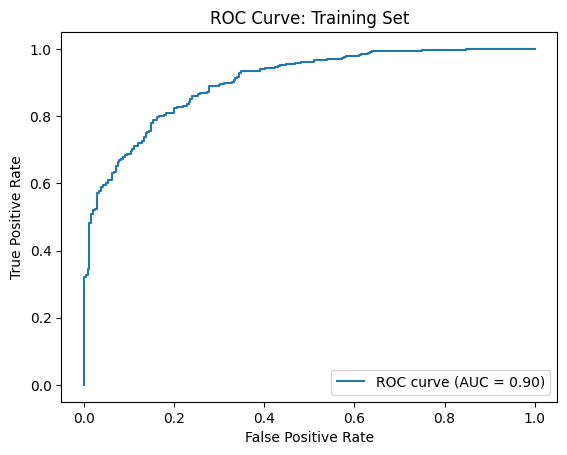

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 1..................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[11 20]
 [ 4 65]]
                  precision    recall  f1-score   support

 bad credit risk       0.73      0.35      0.48        31
good credit risk       0.76      0.94      0.84        69

        accuracy                           0.76       100
       macro avg       0.75      0.65      0.66       100
    weighted avg       0.75      0.76      0.73       100

Accuracy: 0.76
Recall: 0.94
Precision: 0.76
Metrics on training set:
Confusion Matrix (on training set):
 [[ 74 167]
 [ 39 520]]
                  precision    recall  f1-score   support

 bad credit risk       0.65      0.31      0.42       241
good credit risk       0.76      0.93      0.83       559

        accuracy                           0.74       80

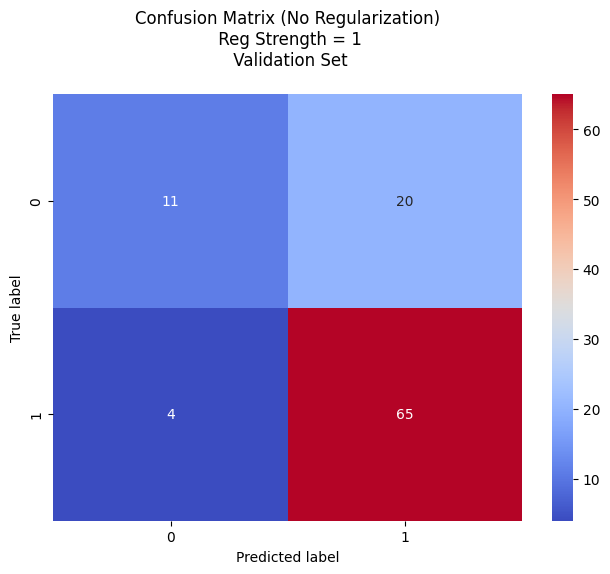

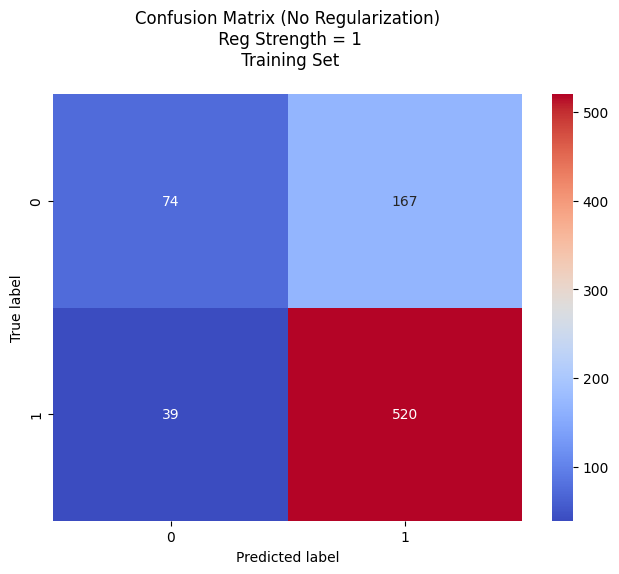

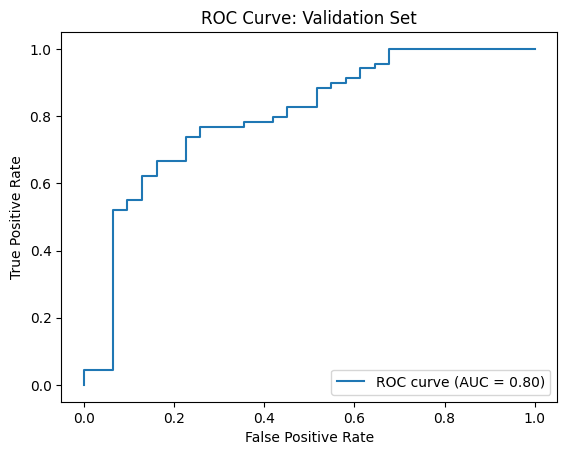

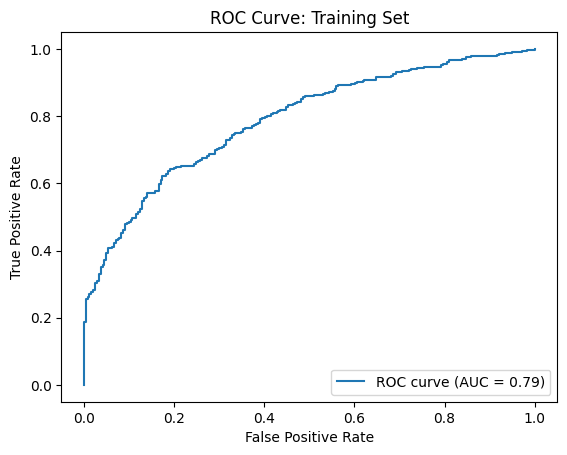

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 100..................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       8

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

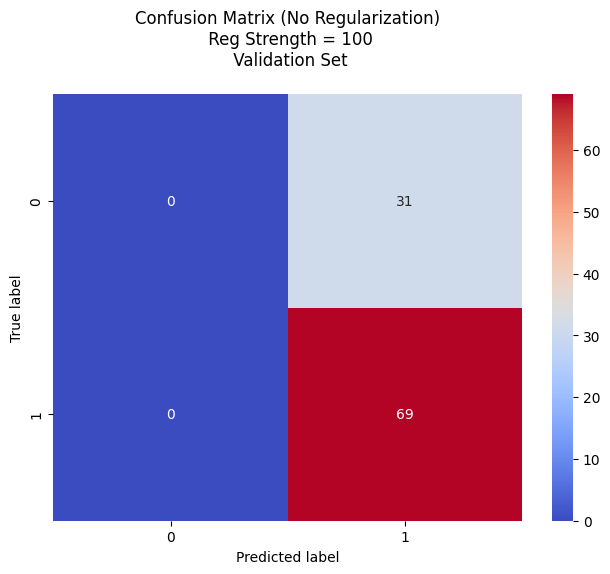

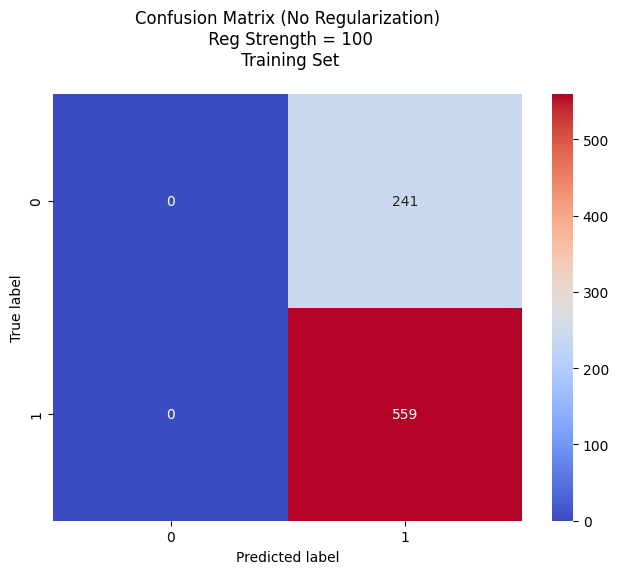

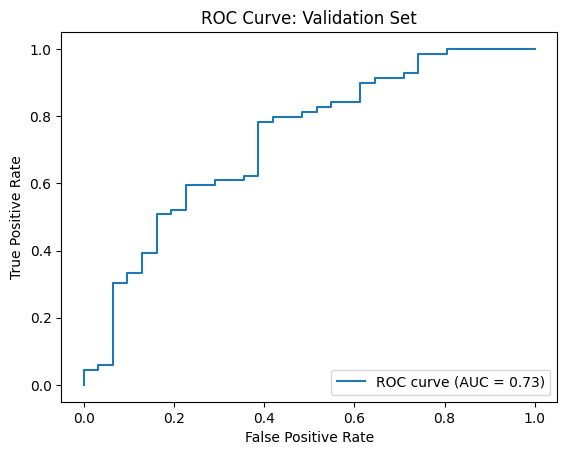

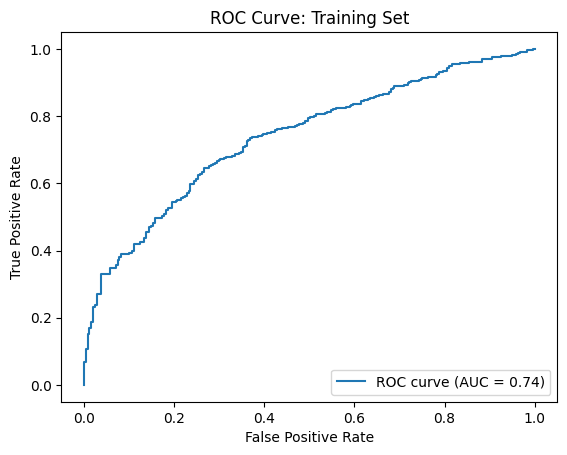

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 10000..................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

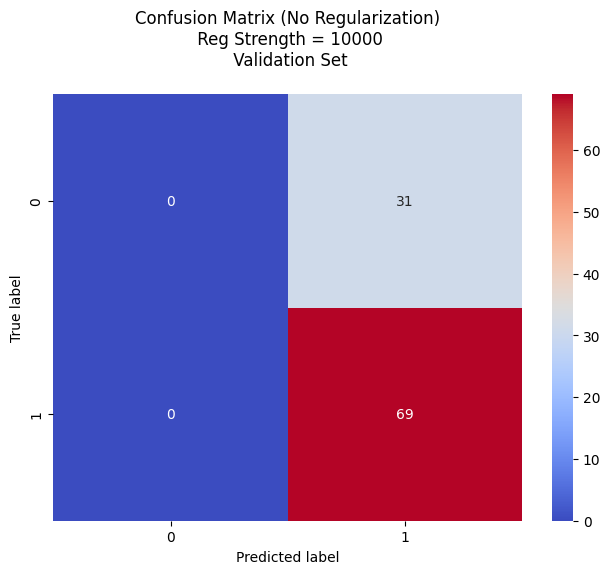

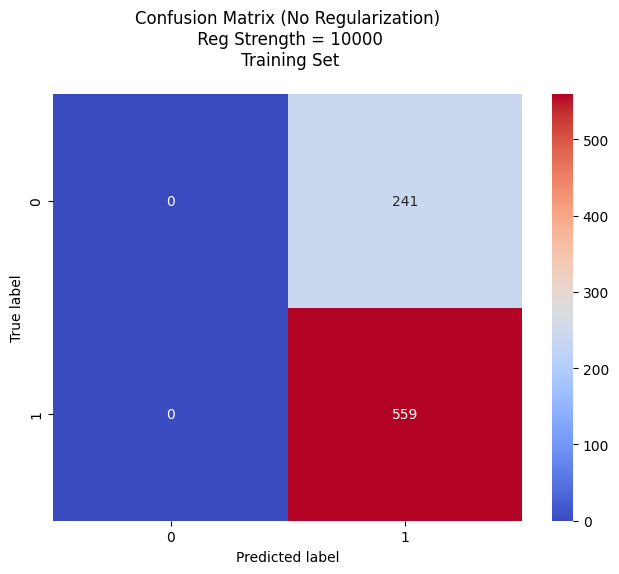

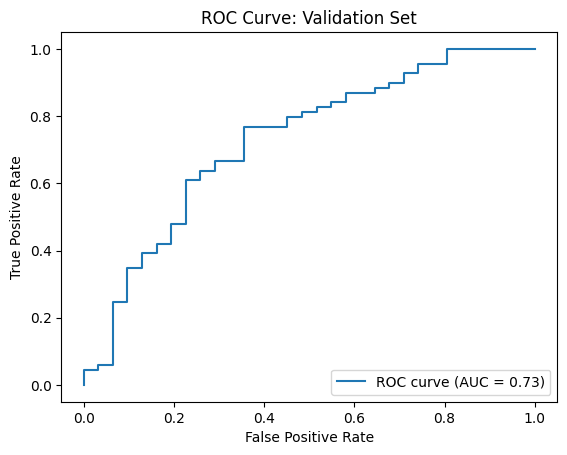

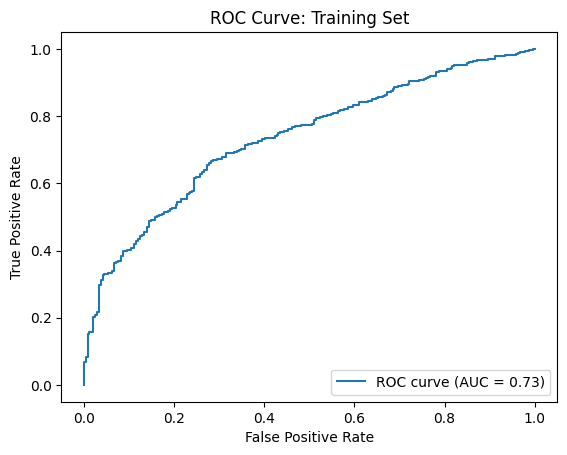

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 1000000..................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

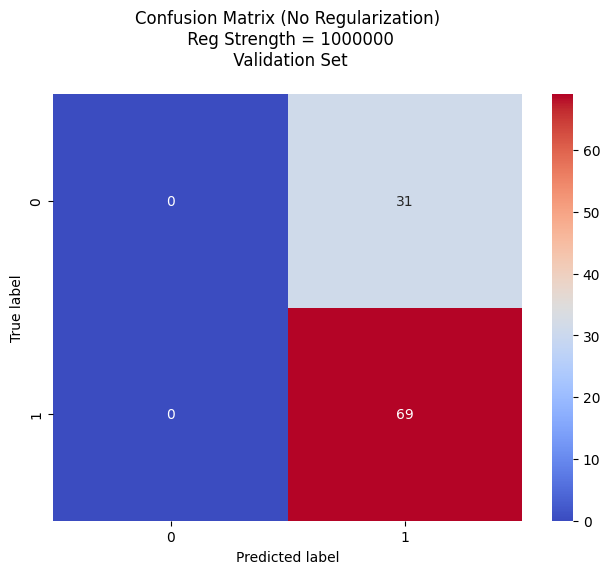

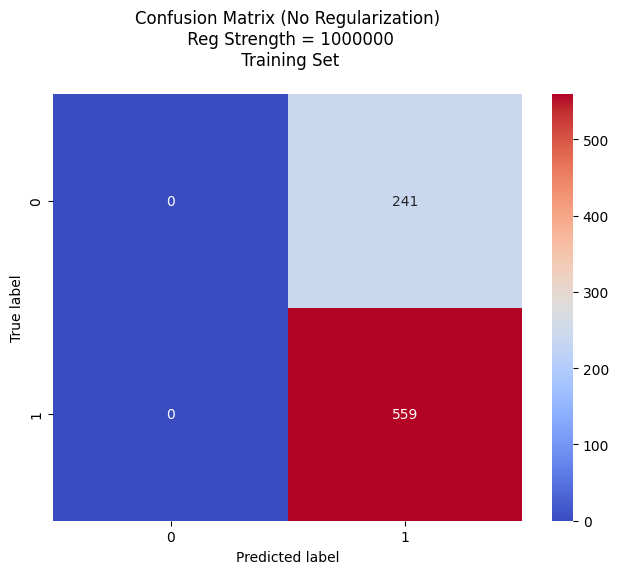

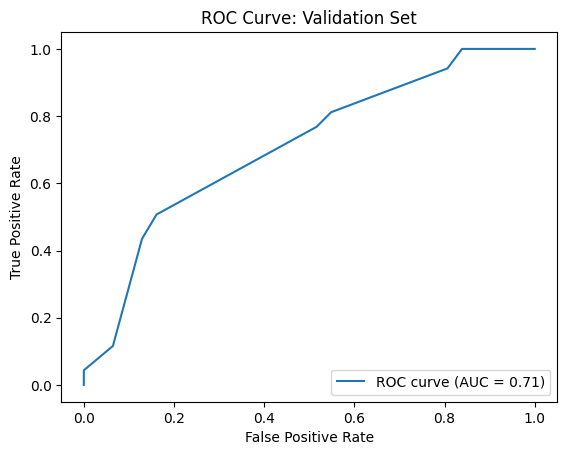

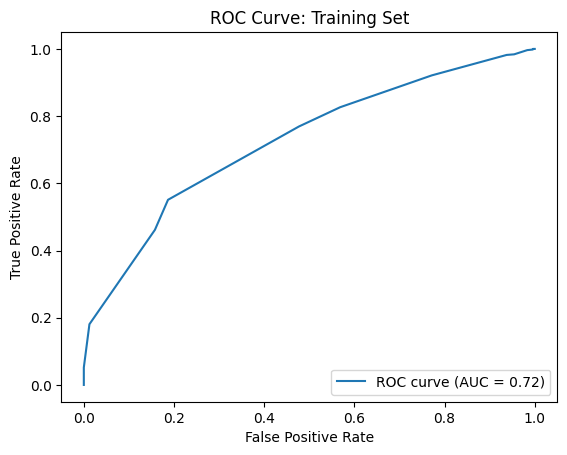

---------------------------------------------------------------------
The best reg_C is 1e-06 with auc = 0.8200093501636279 on validation set.


In [ ]:
# [G] Regularization (at least 6 values)
reg_strengths = [ 10**x for x in range(-6,7,2) ]
best_reg_strength = None
best_auc = -1

# Try different values for regularization strength and see how it performs using * VALIDATION * set
# At the end, choose the best and evaluate model performance on testing set
# Use hidden layes = 15 bc it was found to be the best among those we tested
for reg_strength in reg_strengths:
  print("---------------------------------------------------------------------")
  print(f"Trying Regularisation Inverse Strength C = {reg_strength}..................")
  model_regularized = MLPClassifier(hidden_layer_sizes=(10,), alpha=reg_strength, activation='logistic', solver='adam', max_iter=1000)
  model_regularized.fit(X_train, y_train)
  y_predict_regularized = model_regularized.predict(X_val)
  y_predict_regularized_train = model_regularized.predict(X_train)

  # Metrics
  cnf_matrix = get_confusion_matrix(y_val, y_predict_regularized)
  cnf_matrix_train = get_confusion_matrix(y_train, y_predict_regularized_train)

  print("Metrics on validation set:")
  print(f"Confusion Matrix (on validation set):\n {cnf_matrix}")
  display_metrics(y_val, y_predict_regularized, cnf_matrix, target_names=target_names)

  print("Metrics on training set:")
  print(f"Confusion Matrix (on training set):\n {cnf_matrix_train}")
  display_metrics(y_train, y_predict_regularized_train, cnf_matrix_train, target_names=target_names)


  # Visualize
  visualize_confusion_matrix(cnf_matrix, class_names, f"Confusion Matrix (No Regularization)\n Reg Strength = {reg_strength}\n Validation Set")
  visualize_confusion_matrix(cnf_matrix_train, class_names, f"Confusion Matrix (No Regularization)\n Reg Strength = {reg_strength}\n Training Set")
  y_predict_prob = model_regularized.predict_proba(X_val)[::,1]
  y_predict_prob_train = model_regularized.predict_proba(X_train)[::,1]

  auc = visualize_ROC_plot(y_val, y_predict_prob, class_mapping=class_mapping, title="ROC Curve: Validation Set")
  visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve: Training Set")

  if auc > best_auc:
    best_auc = auc
    best_reg_strength = reg_strength

  print("---------------------------------------------------------------------")

print(f"The best reg_C is {best_reg_strength} with auc = {best_auc} on validation set.")

The best reg_C is 100000000
Confusion Matrix, Reg Strength C=100000000:
 [[ 0 28]
 [ 0 72]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        28
good credit risk       0.72      1.00      0.84        72

        accuracy                           0.72       100
       macro avg       0.36      0.50      0.42       100
    weighted avg       0.52      0.72      0.60       100



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


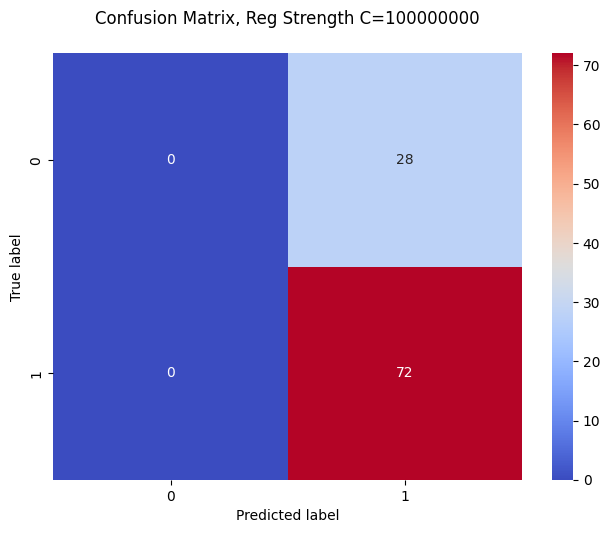

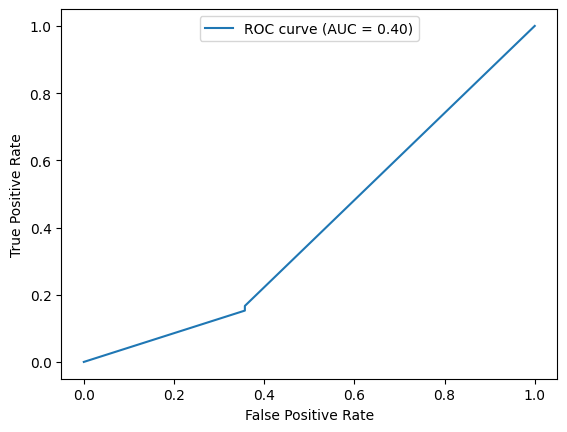

In [ ]:
# [G] - regularization cont.
print(f"The best reg_C is {best_reg_strength}")

# Train the model (15 hidden layers) one last time with best regularization strength and test on test set
model_final = MLPClassifier(hidden_layer_sizes=(15,), alpha=best_reg_strength, activation='logistic', solver='adam', max_iter=1000)
model_final.fit(X_train, y_train)
y_predict_final = model_final.predict(X_test)

# Confusion Matrix
cnf_matrix_final = metrics.confusion_matrix(y_test, y_predict_final)
print(f"Confusion Matrix, Reg Strength C={best_reg_strength}:\n {cnf_matrix_final}")

# Evaluation Metrics
print(metrics.classification_report(y_test, y_predict_final, target_names=target_names))

# Visualize
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix_final), annot=True, cmap="coolwarm" ,fmt='g')
ax.xaxis.set_label_position("bottom")
plt.tight_layout()
plt.title(f"Confusion Matrix, Reg Strength C={best_reg_strength}", y=1.05)
plt.xlabel("Predicted label")
plt.ylabel("True label")

# Visualize ROC curve
plt.figure()
y_predict_final_prob = model_final.predict_proba(X_test)[::,1]
y_test_numeric = y_test.replace({'bad': 0, 'good': 1})
fpr, tpr, _ = metrics.roc_curve(y_test_numeric,  y_predict_final_prob)
auc = metrics.roc_auc_score(y_test_numeric, y_predict_final_prob)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=9)
plt.show()

# SECTION [G] DONE ✅ (Everything Finished)

---------------------------------------------------------------------
Trying learning rate = 1e-05............................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       800
       macro avg       0.35      0.50      0.41       800
    weighted avg 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

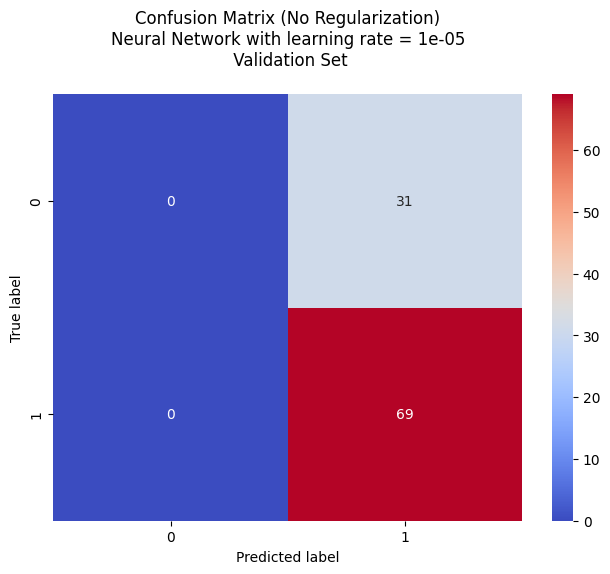

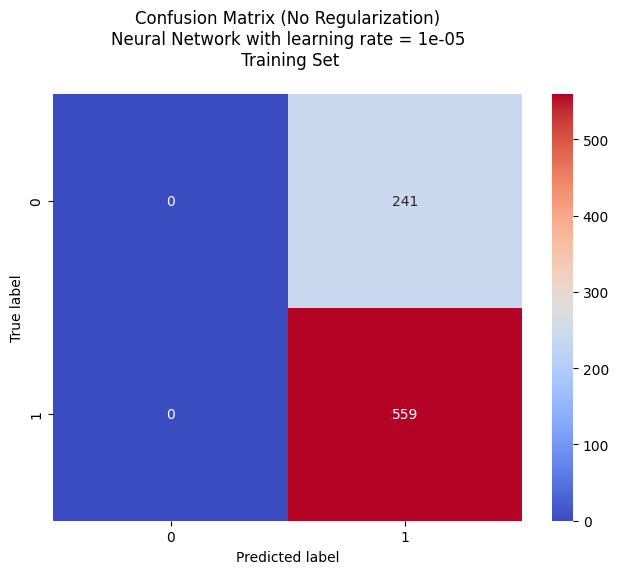

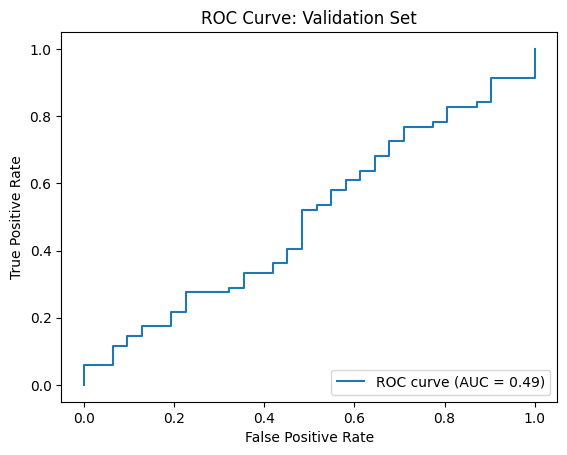

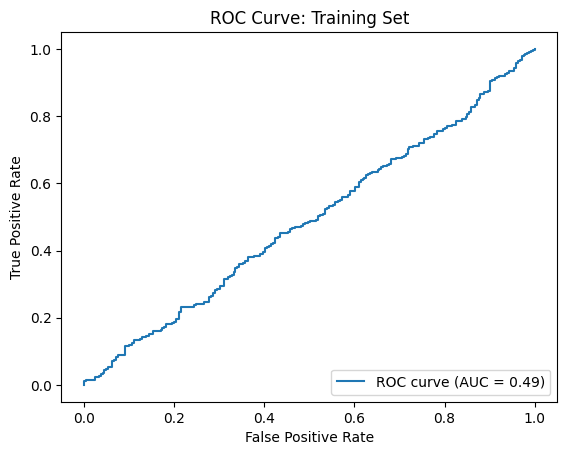

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying learning rate = 0.001............................


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on validation set:
Confusion Matrix (on validation set):
 [[20 11]
 [ 8 61]]
                  precision    recall  f1-score   support

 bad credit risk       0.71      0.65      0.68        31
good credit risk       0.85      0.88      0.87        69

        accuracy                           0.81       100
       macro avg       0.78      0.76      0.77       100
    weighted avg       0.81      0.81      0.81       100

Accuracy: 0.81
Recall: 0.88
Precision: 0.85
Metrics on training set:
Confusion Matrix (on training set):
 [[156  85]
 [ 38 521]]
                  precision    recall  f1-score   support

 bad credit risk       0.80      0.65      0.72       241
good credit risk       0.86      0.93      0.89       559

        accuracy                           0.85       800
       macro avg       0.83      0.79      0.81       800
    weighted avg       0.84      0.85      0.84       800

Accuracy: 0.85
Recall: 0.93
Precision: 0.86
----------------------------------------

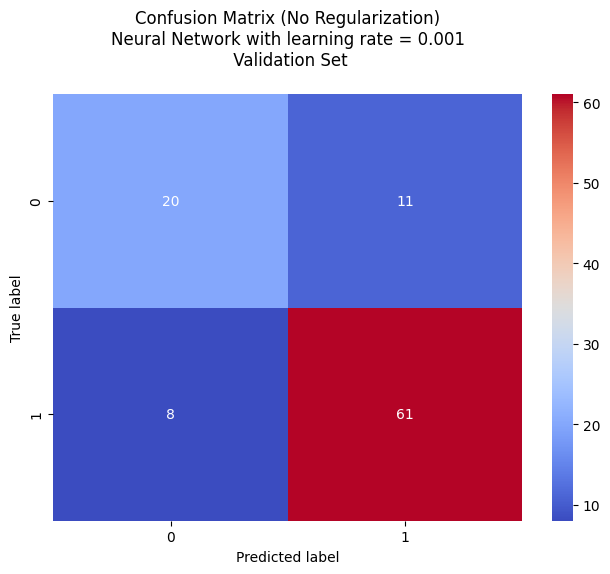

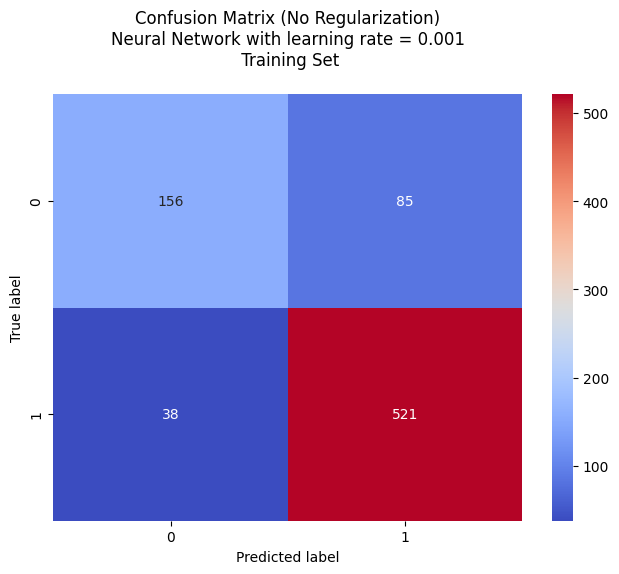

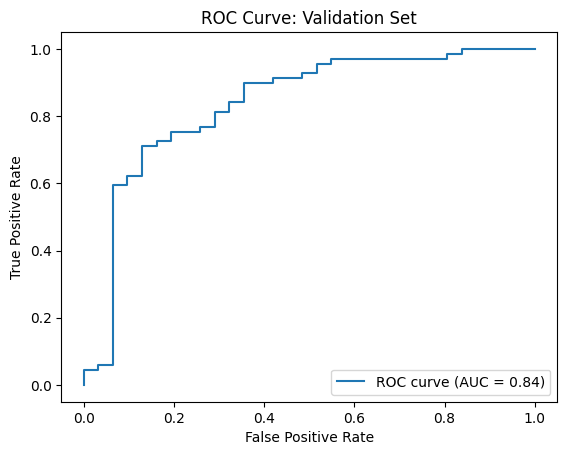

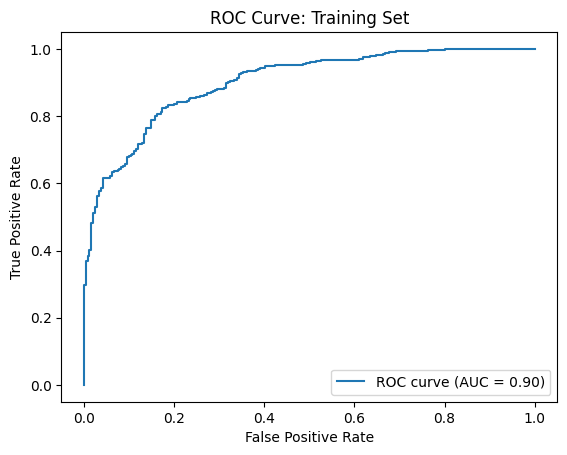

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying learning rate = 0.1............................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[19 12]
 [17 52]]
                  precision    recall  f1-score   support

 bad credit risk       0.53      0.61      0.57        31
good credit risk       0.81      0.75      0.78        69

        accuracy                           0.71       100
       macro avg       0.67      0.68      0.67       100
    weighted avg       0.72      0.71      0.72       100

Accuracy: 0.71
Recall: 0.75
Precision: 0.81
Metrics on training set:
Confusion Matrix (on training set):
 [[236   5]
 [  5 554]]
                  precision    recall  f1-score   support

 bad credit risk       0.98      0.98      0.98       241
good credit risk       0.99      0.99      0.99       559

        accuracy                           0.99       800
      

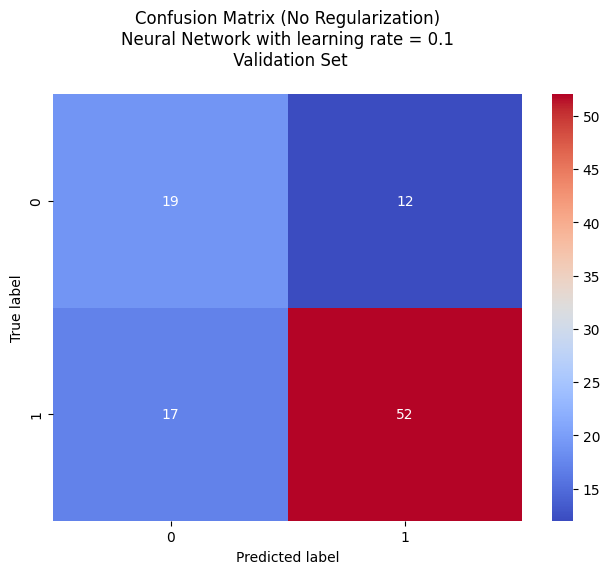

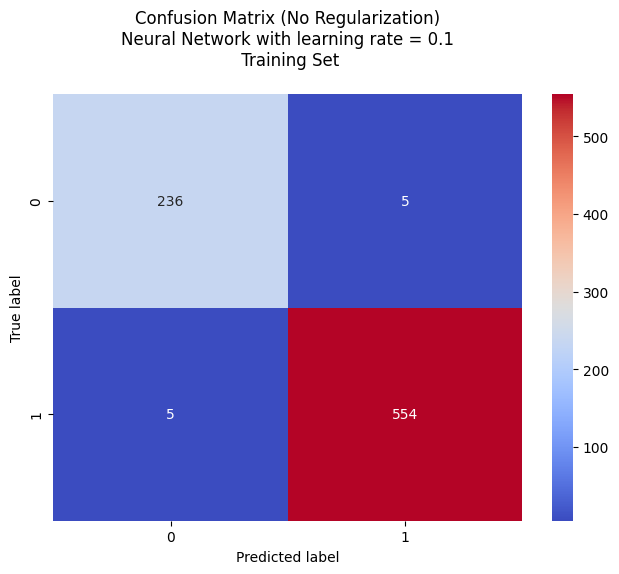

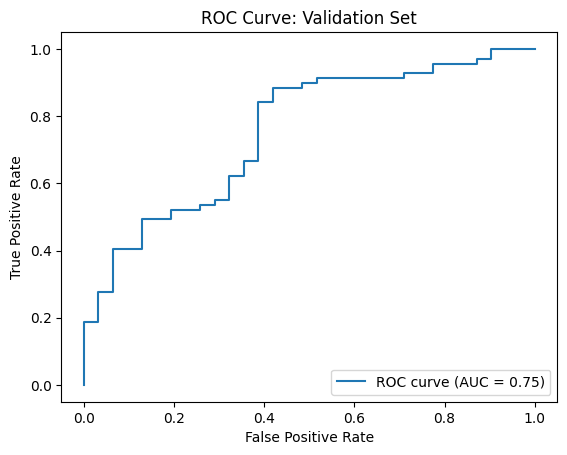

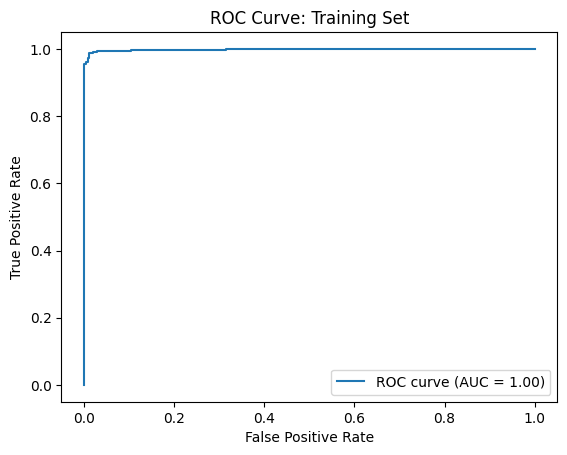

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying learning rate = 10............................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[18 13]
 [24 45]]
                  precision    recall  f1-score   support

 bad credit risk       0.43      0.58      0.49        31
good credit risk       0.78      0.65      0.71        69

        accuracy                           0.63       100
       macro avg       0.60      0.62      0.60       100
    weighted avg       0.67      0.63      0.64       100

Accuracy: 0.63
Recall: 0.65
Precision: 0.78
Metrics on training set:
Confusion Matrix (on training set):
 [[176  65]
 [186 373]]
                  precision    recall  f1-score   support

 bad credit risk       0.49      0.73      0.58       241
good credit risk       0.85      0.67      0.75       559

        accuracy                           0.69       800
       

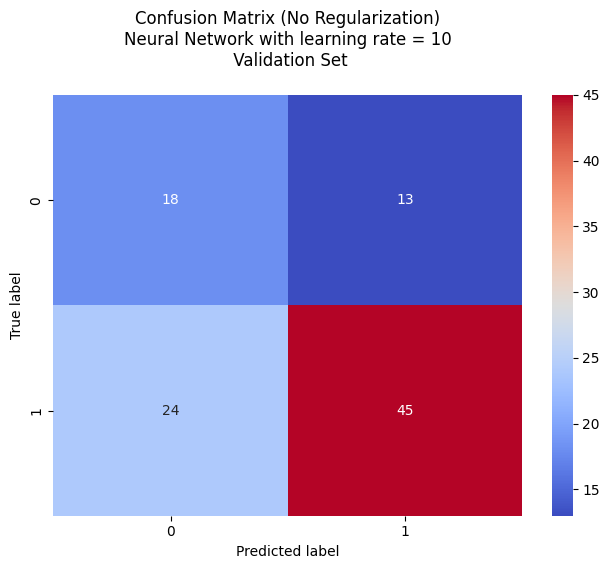

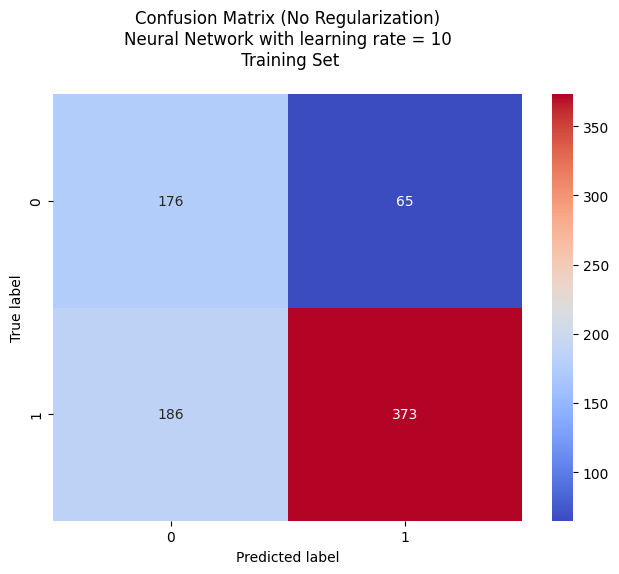

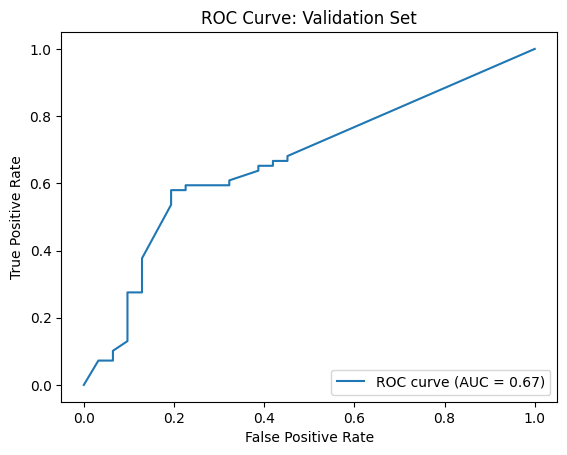

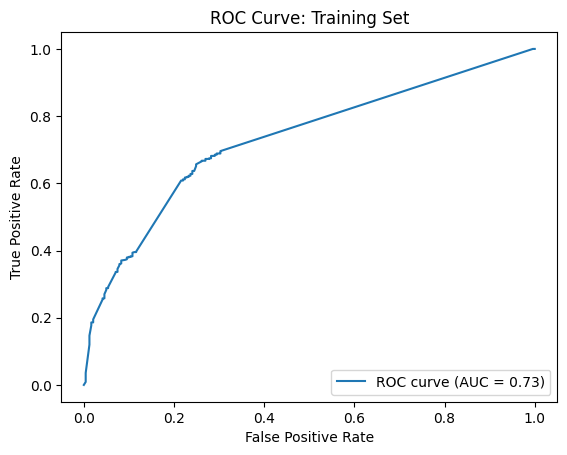

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying learning rate = 1000............................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       800
       macro avg       0.35      0.50      0.41       800
    weighted avg       0.49      0.70      0.57       800

Accuracy: 0.70
Recall: 1.0
Precision: 0.7
--------------------------------------------------------


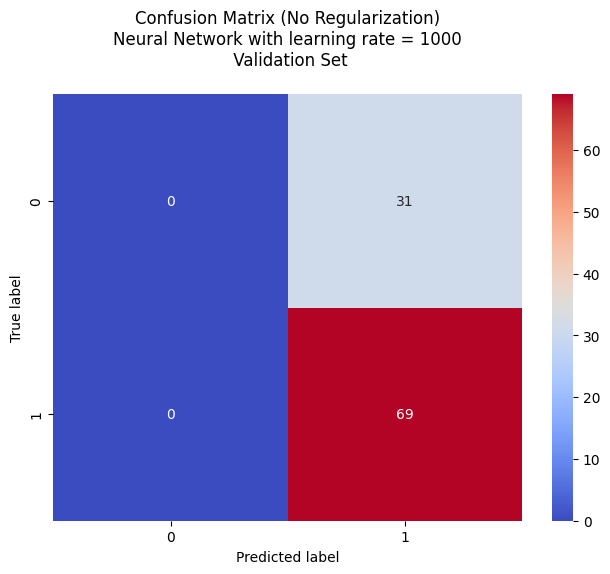

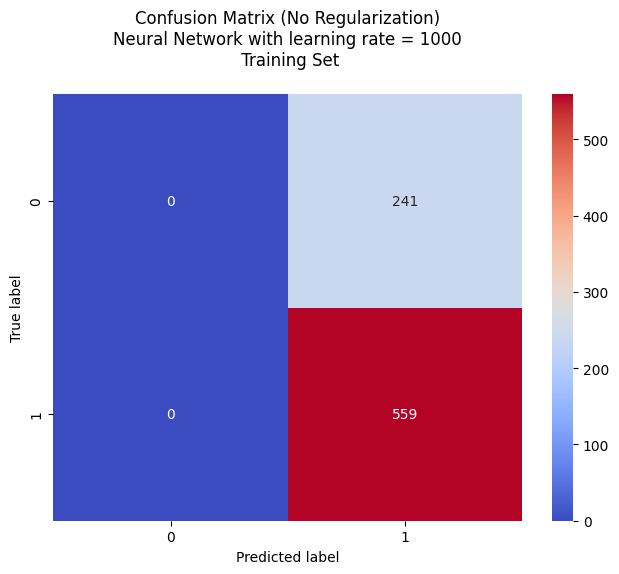

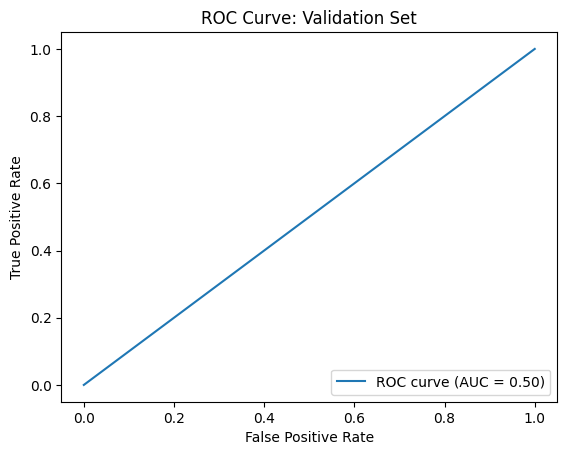

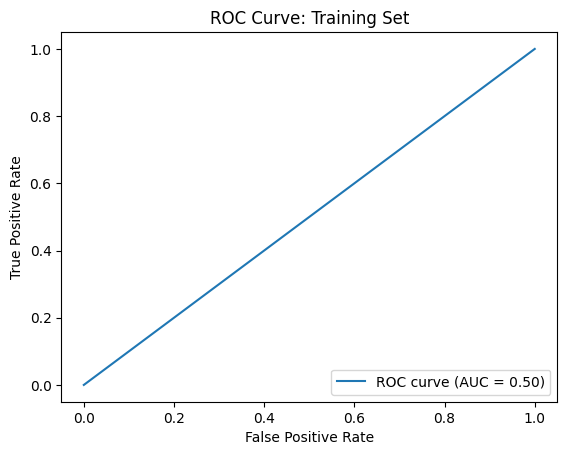

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying learning rate = 100000............................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       800
       macro avg       0.35      0.50      0.41       800
    weighted avg       0.49      0.70      0.57       800

Accuracy: 0.70
Recall: 1.0
Precision: 0.7
--------------------------------------------------------


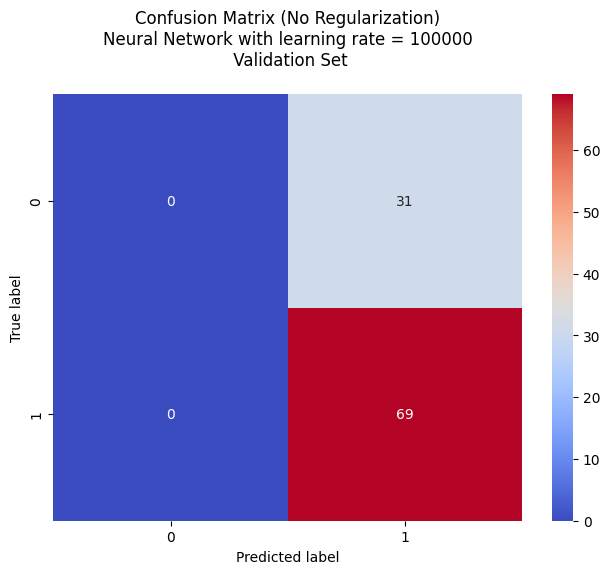

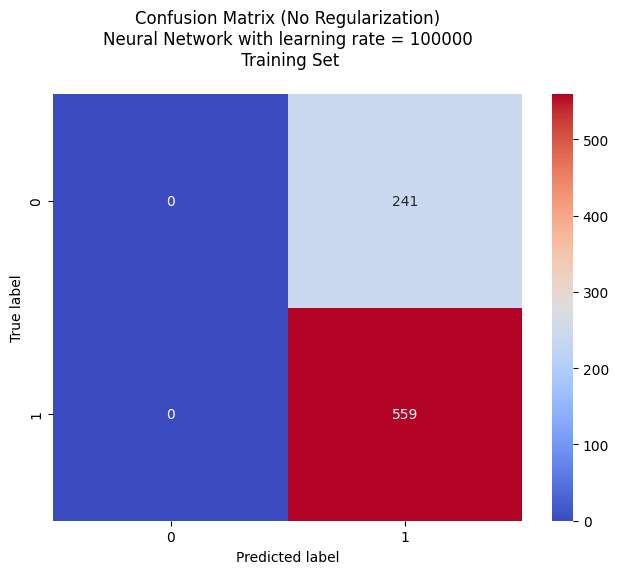

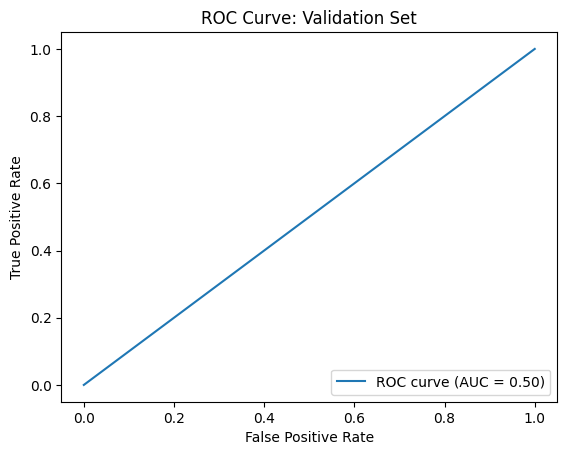

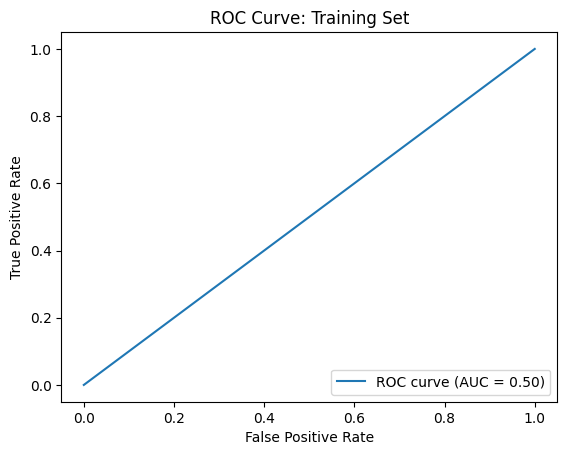

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying learning rate = 10000000............................
Metrics on validation set:
Confusion Matrix (on validation set):
 [[ 0 31]
 [ 0 69]]
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
Confusion Matrix (on training set):
 [[  0 241]
 [  0 559]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       800
       macro avg       0.35      0.50      0.41       800
    weighted avg       0.49      0.70      0.57       800

Accuracy: 0.70
Recall: 1.0
Precision: 0.7
--------------------------------------------------------


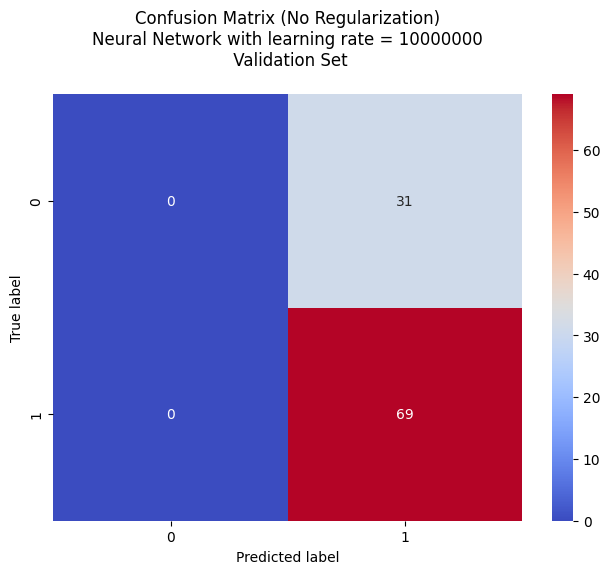

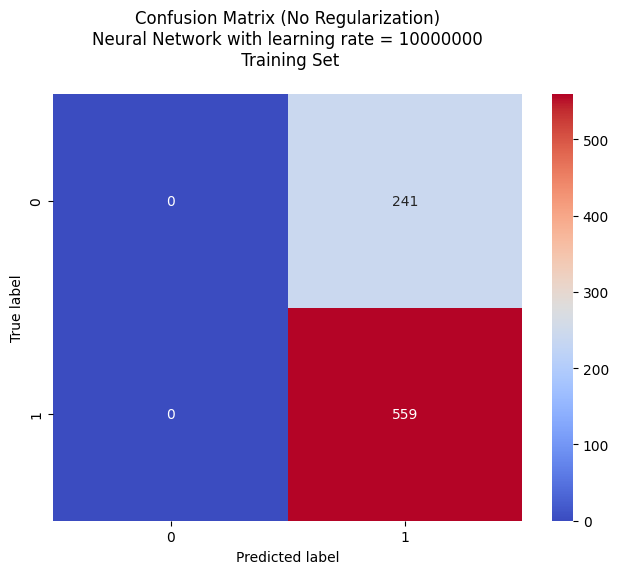

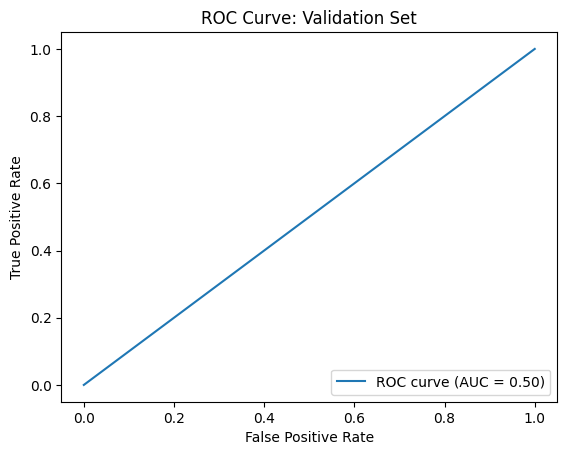

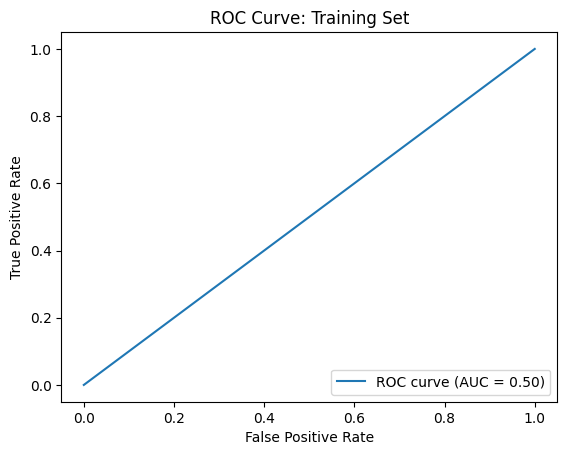

---------------------------------------------------------------------
The best learning rate is 0.001 with auc = 0.8368396446937821 on validation set.


In [ ]:
# [H] Hyperparameter: testing different learning rates
learning_rates = [ 10**x for x in range(-5, 8, 2) ]

best_learning_rate = 10**-5
best_auc_for_learning_rate = -1

# Use 2 hidden layers for simplicity
# Evalute on the validation set
for i in range(len(learning_rates)):
  learning_rate = learning_rates[i]
  print("---------------------------------------------------------------------")
  print(f"Trying learning rate = {learning_rate}............................")
  model = MLPClassifier(hidden_layer_sizes=(10,), alpha=0.000001, activation='logistic', solver='adam', max_iter=1000, learning_rate='constant', learning_rate_init=learning_rate)
  model.fit(X_train, y_train)
  y_predict = model.predict(X_val)
  y_predict_train = model.predict(X_train)

  # Metrics
  cnf_matrix = get_confusion_matrix(y_val, y_predict)
  cnf_matrix_train = get_confusion_matrix(y_train, y_predict_train)

  print("Metrics on validation set:")
  print(f"Confusion Matrix (on validation set):\n {cnf_matrix}")
  display_metrics(y_val, y_predict, cnf_matrix, target_names=target_names)

  print("Metrics on training set:")
  print(f"Confusion Matrix (on training set):\n {cnf_matrix_train}")
  display_metrics(y_train, y_predict_train, cnf_matrix_train, target_names=target_names)

  print("--------------------------------------------------------")

  # Visualize
  visualize_confusion_matrix(cnf_matrix, class_names, f"Confusion Matrix (No Regularization)\nNeural Network with learning rate = {learning_rate}\n Validation Set")
  visualize_confusion_matrix(cnf_matrix_train, class_names, f"Confusion Matrix (No Regularization)\nNeural Network with learning rate = {learning_rate}\n Training Set")
  y_predict_prob = model.predict_proba(X_val)[::,1]
  y_predict_prob_train = model.predict_proba(X_train)[::,1]

  auc = visualize_ROC_plot(y_val, y_predict_prob, class_mapping=class_mapping, title="ROC Curve: Validation Set")
  visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve: Training Set")

  if auc > best_auc_for_learning_rate:
    best_auc_for_learning_rate = auc
    best_learning_rate = learning_rate

  print("---------------------------------------------------------------------")

print(f"The best learning rate is {best_learning_rate} with auc = {best_auc_for_learning_rate} on validation set.")

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics on test set:
Confusion Matrix (on test set):
 [[10 18]
 [11 61]]
                  precision    recall  f1-score   support

 bad credit risk       0.48      0.36      0.41        28
good credit risk       0.77      0.85      0.81        72

        accuracy                           0.71       100
       macro avg       0.62      0.60      0.61       100
    weighted avg       0.69      0.71      0.70       100

Accuracy: 0.71
Recall: 0.85
Precision: 0.77
Metrics on training set:
Confusion Matrix (on training set):
 [[155  86]
 [ 34 525]]
                  precision    recall  f1-score   support

 bad credit risk       0.82      0.64      0.72       241
good credit risk       0.86      0.94      0.90       559

        accuracy                           0.85       800
       macro avg       0.84      0.79      0.81       800
    weighted avg       0.85      0.85      0.84       800

Accuracy: 0.85
Recall: 0.94
Precision: 0.86


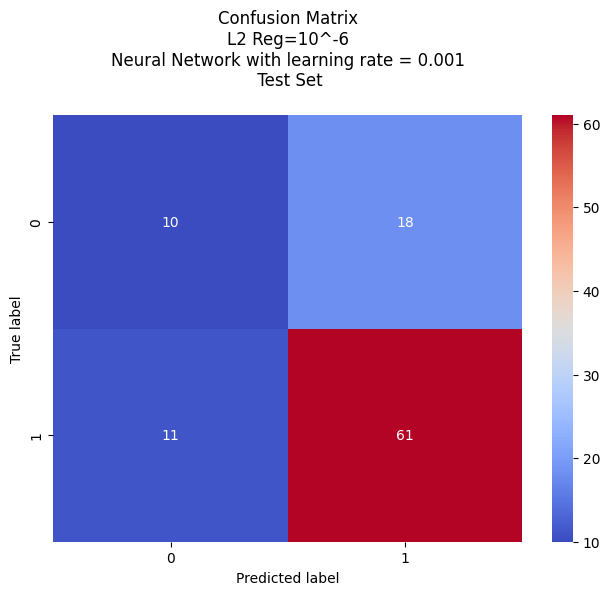

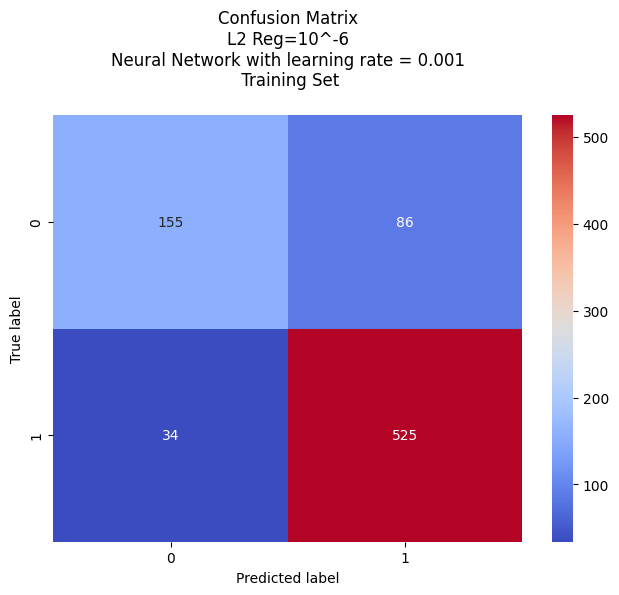

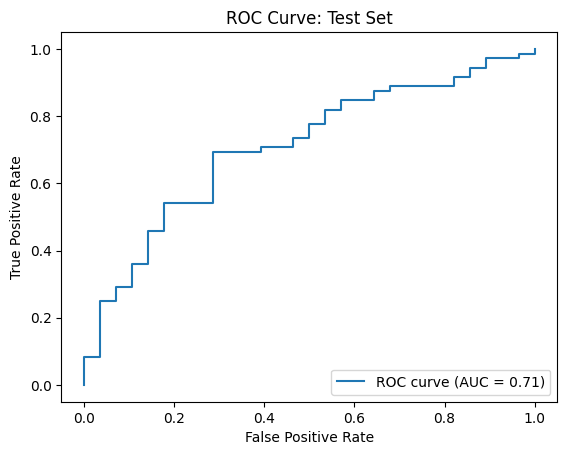

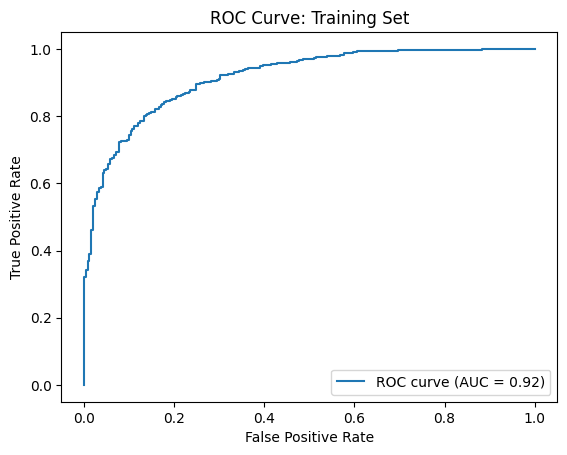

0.9153051908045635

In [ ]:
# [I] Final Model with best everything - test it on the test set

# print(f"Best regularization strength (L2): {best_reg_strength}")
# print(f"Best learning rate: {best_learning_rate}")
# print(f"Best number of hidden layers: {best_hidden_layers}")
# print(f"Best regularization: NO regularization")


model = MLPClassifier(hidden_layer_sizes=(10,), activation='logistic', solver='adam', max_iter=1000, learning_rate='constant', learning_rate_init=0.001, alpha=0.000001)
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
y_predict_train = model.predict(X_train)

# Metrics
cnf_matrix = get_confusion_matrix(y_test, y_predict)
cnf_matrix_train = get_confusion_matrix(y_train, y_predict_train)

print("Metrics on test set:")
print(f"Confusion Matrix (on test set):\n {cnf_matrix}")
display_metrics(y_test, y_predict, cnf_matrix, target_names=target_names)

print("Metrics on training set:")
print(f"Confusion Matrix (on training set):\n {cnf_matrix_train}")
display_metrics(y_train, y_predict_train, cnf_matrix_train, target_names=target_names)

# Visualize
visualize_confusion_matrix(cnf_matrix, class_names, f"Confusion Matrix\nL2 Reg=10^-6\nNeural Network with learning rate = 0.001\n Test Set")
visualize_confusion_matrix(cnf_matrix_train, class_names, f"Confusion Matrix\nL2 Reg=10^-6\nNeural Network with learning rate = 0.001\n Training Set")
y_predict_prob = model.predict_proba(X_test)[::,1]
y_predict_prob_train = model.predict_proba(X_train)[::,1]

visualize_ROC_plot(y_test, y_predict_prob, class_mapping=class_mapping, title="ROC Curve: Test Set")
visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve: Training Set")
